In [1]:
!pip install pandas numpy matplotlib seaborn plotly ydata-profiling scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.8 MB/s eta 0:00:00


In [2]:
import os
#1 Crear las carpetas de salida
os.makedirs("solaris/output", exist_ok=True)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from ydata_profiling import ProfileReport
from scipy import stats


/tmp/ipykernel_3111/3189681568.py:6: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/PROYECTO EN CIENCIA DE DATOS 2/SOLARIS_FrescaMar_cartera_credito.csv')
df

,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo
0,CLI-100000,71,11525805,Posgrado,Cali,2021-04-07,4484274,26,48,Al día,790.0
1,CLI-100001,25,0,Tecnólogo,SANTA MARTA,2015-04-02,476422,32,36,Al día,747.0
2,CLI-100002,34,2186293,Secundaria,SANTA MARTA,2020-11-25,362454,3,6,Al día,367.0
3,CLI-100003,73,0,Tecnólogo,ibague,2016-11-23,2225927,28,48,Al día,533.0
4,CLI-100004,45,0,Universitario,CARTAGENA,2023-06-18,8870010,19,48,Al día,685.0
...,...,...,...,...,...,...,...,...,...,...,...
14995,CLI-114995,21,6348411,Universitario,Medellin,2020-02-21,23226872,13,48,Moroso,808.0
14996,CLI-114996,26,4687892,Universitario,CÚCUTA,2017-06-11,446575,10,12,Al día,509.0
14997,CLI-114997,51,0,Universitario,bogota,2021-11-06,3614378,11,24,Al día,483.0
14998,CLI-114998,29,1155799,Secundaria,SANTA MARTA,2019-06-24,0,18,18,Cancelado,449.0


In [6]:
filas, columnas = df.shape

print(f"Número de filas: {filas:,}")
print(f"Número de columnas: {columnas}")
print(f"Dimensiones completas: {df.shape}")

Número de filas: 15,000
Número de columnas: 11
Dimensiones completas: (15000, 11)


In [7]:
df.dtypes.value_counts()

,count
object,5
int64,5
float64,1


In [8]:
df.dtypes

,0
id_cliente,object
edad,int64
ingreso_mensual,int64
nivel_educativo,object
ciudad,object
fecha_vinculacion,object
saldo_actual,int64
cuotas_pagadas,int64
cuotas_totales,int64
estado_cuenta,object


In [9]:
tipos_columnas = pd.DataFrame({
    'columna': df.columns,
    'tipo_detectado': df.dtypes.astype(str).values
})

tipos_columnas

,columna,tipo_detectado
0,id_cliente,object
1,edad,int64
2,ingreso_mensual,int64
3,nivel_educativo,object
4,ciudad,object
5,fecha_vinculacion,object
6,saldo_actual,int64
7,cuotas_pagadas,int64
8,cuotas_totales,int64
9,estado_cuenta,object


In [10]:
memoria_bytes = df.memory_usage(deep=True).sum()
memoria_mb = memoria_bytes / (1024 ** 2)

print(f"Memoria utilizada: {memoria_bytes:,} bytes")
print(f"Memoria utilizada: {memoria_mb:.2f} MB")

Memoria utilizada: 5,572,427 bytes
Memoria utilizada: 5.31 MB


In [11]:
df.head()

,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo
0,CLI-100000,71,11525805,Posgrado,Cali,2021-04-07,4484274,26,48,Al día,790.0
1,CLI-100001,25,0,Tecnólogo,SANTA MARTA,2015-04-02,476422,32,36,Al día,747.0
2,CLI-100002,34,2186293,Secundaria,SANTA MARTA,2020-11-25,362454,3,6,Al día,367.0
3,CLI-100003,73,0,Tecnólogo,ibague,2016-11-23,2225927,28,48,Al día,533.0
4,CLI-100004,45,0,Universitario,CARTAGENA,2023-06-18,8870010,19,48,Al día,685.0


In [12]:
#2 Configurar el informe
perfil=ProfileReport(df, explorative=True, minimal=False)
perfil.to_file("solaris/output/Perfil_Final.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 11.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [13]:
import matplotlib.pyplot as plt

carpeta_salida = "solaris/output"
os.makedirs(carpeta_salida, exist_ok=True)

# PASO 3. Distribuciones univariadas de variables numéricas

In [14]:
columnas_numericas = df.select_dtypes(include=[np.number])

print(f"Cantidad de columnas numéricas: {columnas_numericas.shape[1]}")
print("Columnas numéricas encontradas:")

for columna in columnas_numericas.columns:
    print(f"- {columna}")

Cantidad de columnas numéricas: 6
Columnas numéricas encontradas:
- edad
- ingreso_mensual
- saldo_actual
- cuotas_pagadas
- cuotas_totales
- score_externo


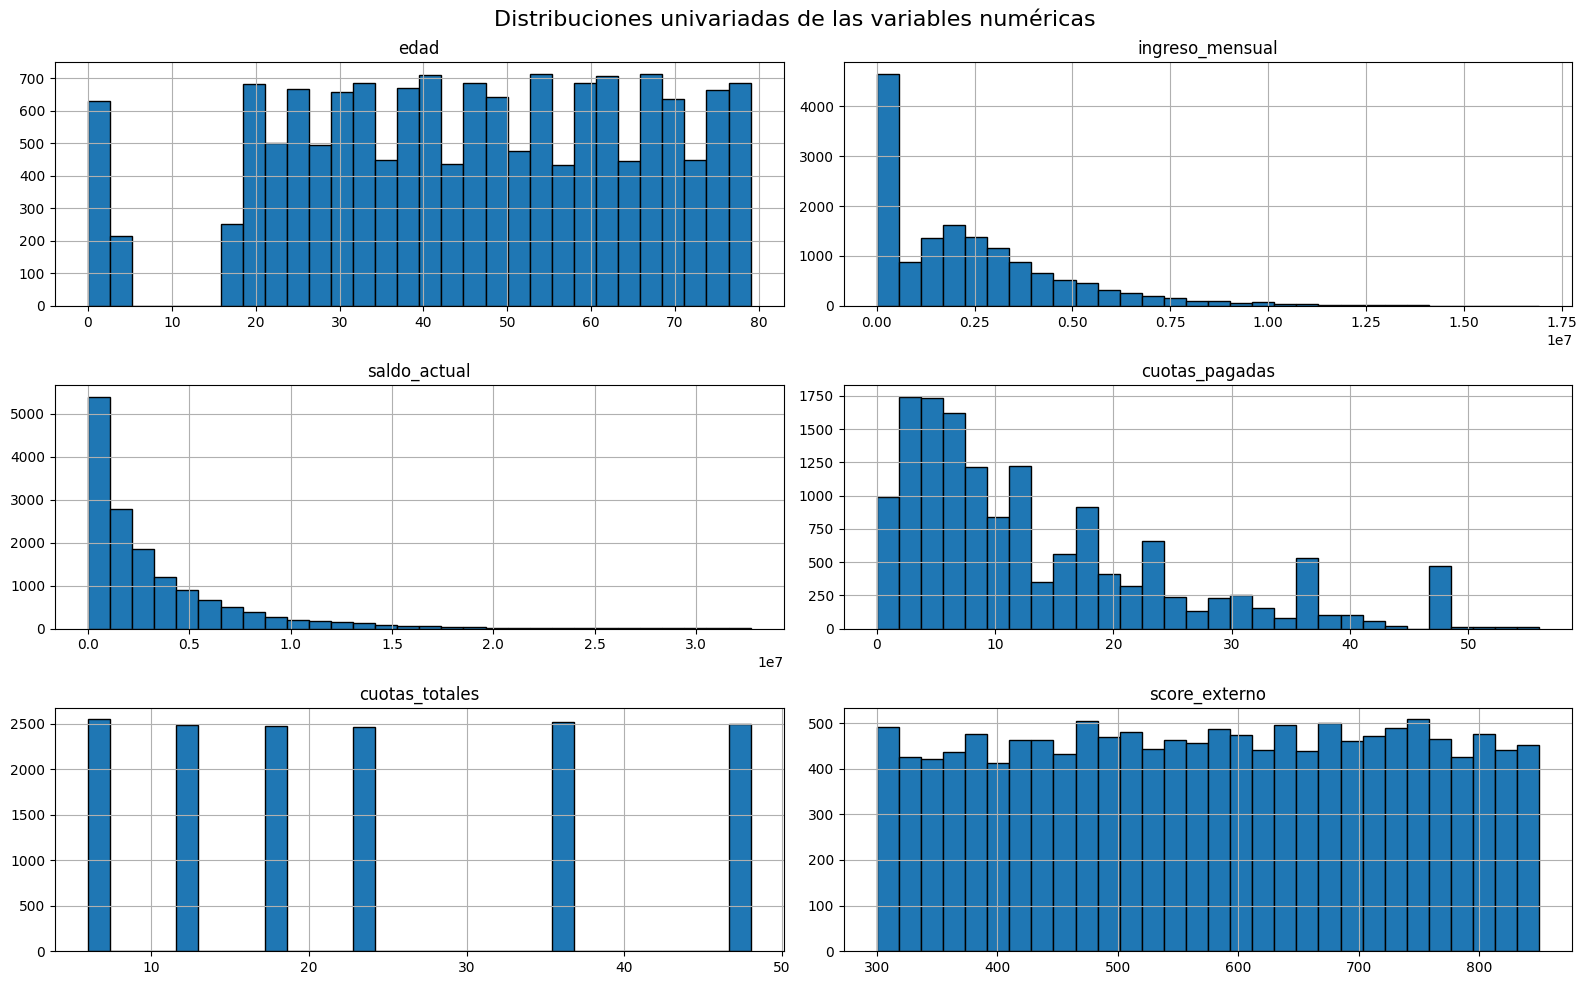

Imagen guardada en: solaris/output/distribuciones_univariadas.png


In [15]:
columnas_numericas = df.select_dtypes(include=[np.number])

columnas_numericas.hist(
    bins=30,
    figsize=(16, 10),
    edgecolor="black"
)

plt.suptitle(
    "Distribuciones univariadas de las variables numéricas",
    fontsize=16
)

plt.tight_layout()

ruta_histogramas = os.path.join(
    carpeta_salida,
    "distribuciones_univariadas.png"
)

plt.savefig(
    ruta_histogramas,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Imagen guardada en:", ruta_histogramas)

In [16]:
import os
import numpy as np
import pandas as pd

# Carpeta donde se guardó el informe anterior
carpeta_salida = "solaris/output"
os.makedirs(carpeta_salida, exist_ok=True)

# Seleccionar únicamente columnas numéricas
df_numericas = df.select_dtypes(include=[np.number])

alertas = []

for columna in df_numericas.columns:

    datos = df_numericas[columna].dropna()

    if datos.empty:
        continue

    # ---------------------------------------------------------
    # 1. Buscar distribución aproximadamente uniforme
    #    Posible identificador numérico disfrazado
    # ---------------------------------------------------------
    if datos.nunique() >= 20:

        frecuencias, _ = np.histogram(datos, bins=20)

        promedio_bins = frecuencias.mean()

        if promedio_bins > 0:
            coeficiente_variacion = frecuencias.std() / promedio_bins
        else:
            coeficiente_variacion = np.nan

        proporcion_unicos = datos.nunique() / len(datos)

        # Regla exploratoria:
        # - Más del 80 % de valores son únicos
        # - Las frecuencias de los bins son similares
        if (
            proporcion_unicos > 0.80
            and coeficiente_variacion < 0.20
        ):
            alertas.append({
                "columna": columna,
                "tipo_alerta": "Posible distribución uniforme",
                "detalle": (
                    f"{proporcion_unicos:.2%} de los valores son únicos "
                    f"y el coeficiente de variación entre bins es "
                    f"{coeficiente_variacion:.3f}. "
                    "Podría tratarse de un ID numérico disfrazado."
                )
            })

    # ---------------------------------------------------------
    # 2. Buscar un solo bin dominante superior al 95 %
    # ---------------------------------------------------------
    frecuencias, limites = np.histogram(datos, bins=30)

    posicion_dominante = np.argmax(frecuencias)
    proporcion_dominante = frecuencias[posicion_dominante] / len(datos)

    if proporcion_dominante > 0.95:

        limite_inferior = limites[posicion_dominante]
        limite_superior = limites[posicion_dominante + 1]

        alertas.append({
            "columna": columna,
            "tipo_alerta": "Un solo bin dominante",
            "detalle": (
                f"El {proporcion_dominante:.2%} de los registros se encuentra "
                f"entre {limite_inferior:.2f} y {limite_superior:.2f}. "
                "La variable podría ser casi constante o tener un valor "
                "utilizado como código."
            )
        })


# -------------------------------------------------------------
# 3. Buscar valores imposibles en la edad
# -------------------------------------------------------------
if "edad" in df.columns:

    edades_negativas = df["edad"] < 0
    edades_mayores_120 = df["edad"] > 120

    if edades_negativas.any():
        alertas.append({
            "columna": "edad",
            "tipo_alerta": "Edad negativa",
            "detalle": (
                f"Se encontraron {edades_negativas.sum()} registros "
                "con una edad inferior a cero."
            )
        })

    if edades_mayores_120.any():
        alertas.append({
            "columna": "edad",
            "tipo_alerta": "Edad superior a 120",
            "detalle": (
                f"Se encontraron {edades_mayores_120.sum()} registros "
                "con una edad superior a 120 años."
            )
        })


# -------------------------------------------------------------
# 4. Detectar columnas que posiblemente representan porcentajes
# -------------------------------------------------------------
palabras_porcentaje = [
    "porcentaje",
    "percent",
    "porc",
    "pct",
    "tasa"
]

columnas_porcentaje = [
    columna
    for columna in df_numericas.columns
    if any(
        palabra in columna.lower()
        for palabra in palabras_porcentaje
    )
]

for columna in columnas_porcentaje:

    valores_mayores_100 = df[columna] > 100
    valores_negativos = df[columna] < 0

    if valores_mayores_100.any():
        alertas.append({
            "columna": columna,
            "tipo_alerta": "Porcentaje superior a 100",
            "detalle": (
                f"Se encontraron {valores_mayores_100.sum()} registros "
                "con valores superiores a 100."
            )
        })

    if valores_negativos.any():
        alertas.append({
            "columna": columna,
            "tipo_alerta": "Porcentaje negativo",
            "detalle": (
                f"Se encontraron {valores_negativos.sum()} registros "
                "con valores inferiores a cero."
            )
        })


# -------------------------------------------------------------
# Crear y mostrar el informe de alertas
# -------------------------------------------------------------
alertas_df = pd.DataFrame(
    alertas,
    columns=["columna", "tipo_alerta", "detalle"]
)

if alertas_df.empty:
    print("No se encontraron alertas con las reglas establecidas.")
else:
    print(f"Se encontraron {len(alertas_df)} alertas:")
    display(alertas_df)

# Guardar resultados
ruta_alertas = os.path.join(
    carpeta_salida,
    "alertas_distribuciones.csv"
)

alertas_df.to_csv(
    ruta_alertas,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nResultados guardados en: {ruta_alertas}")

No se encontraron alertas con las reglas establecidas.

Resultados guardados en: solaris/output/alertas_distribuciones.csv


In [17]:
if "edad" in df.columns:

    registros_edad_imposible = df[
        (df["edad"] < 0) |
        (df["edad"] > 120)
    ]

    print(
        f"Cantidad de registros con edades imposibles: "
        f"{len(registros_edad_imposible)}"
    )

    display(
        registros_edad_imposible[
            ["id_cliente", "edad", "fecha_vinculacion", "estado_cuenta"]
        ].head(20)
    )

Cantidad de registros con edades imposibles: 0


,id_cliente,edad,fecha_vinculacion,estado_cuenta


In [18]:
df["ciudad"].value_counts().head(60)

,count
ciudad,
MZL,283
"Manizales, Caldas",274
Villavo,274
PEREIRA,274
Ibagué,268
cucuta,265
PEI,262
pereira,260
"Pereira, Risaralda",258


#PASO 4.

In [19]:
correlacion_pearson = df_numericas.corr(method="pearson")
correlacion_spearman = df_numericas.corr(method="spearman")
correlacion_kendall = df_numericas.corr(method="kendall")

print("Matrices de correlación calculadas correctamente.")

display(correlacion_pearson)
display(correlacion_spearman)
display(correlacion_kendall)

Matrices de correlación calculadas correctamente.


,edad,ingreso_mensual,saldo_actual,cuotas_pagadas,cuotas_totales,score_externo
edad,1.000000,0.005666,-0.022669,0.036941,0.003907,0.001369
ingreso_mensual,0.005666,1.000000,-0.082238,0.068693,-0.012084,-0.009687
saldo_actual,-0.022669,-0.082238,1.000000,-0.160804,0.459640,0.006685
cuotas_pagadas,0.036941,0.068693,-0.160804,1.000000,0.702701,0.008960
cuotas_totales,0.003907,-0.012084,0.459640,0.702701,1.000000,0.005629
score_externo,0.001369,-0.009687,0.006685,0.008960,0.005629,1.000000


,edad,ingreso_mensual,saldo_actual,cuotas_pagadas,cuotas_totales,score_externo
edad,1.000000,0.007033,-0.025535,0.021114,0.003143,0.001975
ingreso_mensual,0.007033,1.000000,-0.178561,0.083774,-0.012912,-0.008272
saldo_actual,-0.025535,-0.178561,1.000000,-0.170505,0.421247,0.002682
cuotas_pagadas,0.021114,0.083774,-0.170505,1.000000,0.718035,0.001750
cuotas_totales,0.003143,-0.012912,0.421247,0.718035,1.000000,0.006260
score_externo,0.001975,-0.008272,0.002682,0.001750,0.006260,1.000000


,edad,ingreso_mensual,saldo_actual,cuotas_pagadas,cuotas_totales,score_externo
edad,1.000000,0.004872,-0.017304,0.014542,0.002314,0.001343
ingreso_mensual,0.004872,1.000000,-0.125219,0.059022,-0.009649,-0.005736
saldo_actual,-0.017304,-0.125219,1.000000,-0.118715,0.324285,0.001798
cuotas_pagadas,0.014542,0.059022,-0.118715,1.000000,0.575727,0.001218
cuotas_totales,0.002314,-0.009649,0.324285,0.575727,1.000000,0.004496
score_externo,0.001343,-0.005736,0.001798,0.001218,0.004496,1.000000


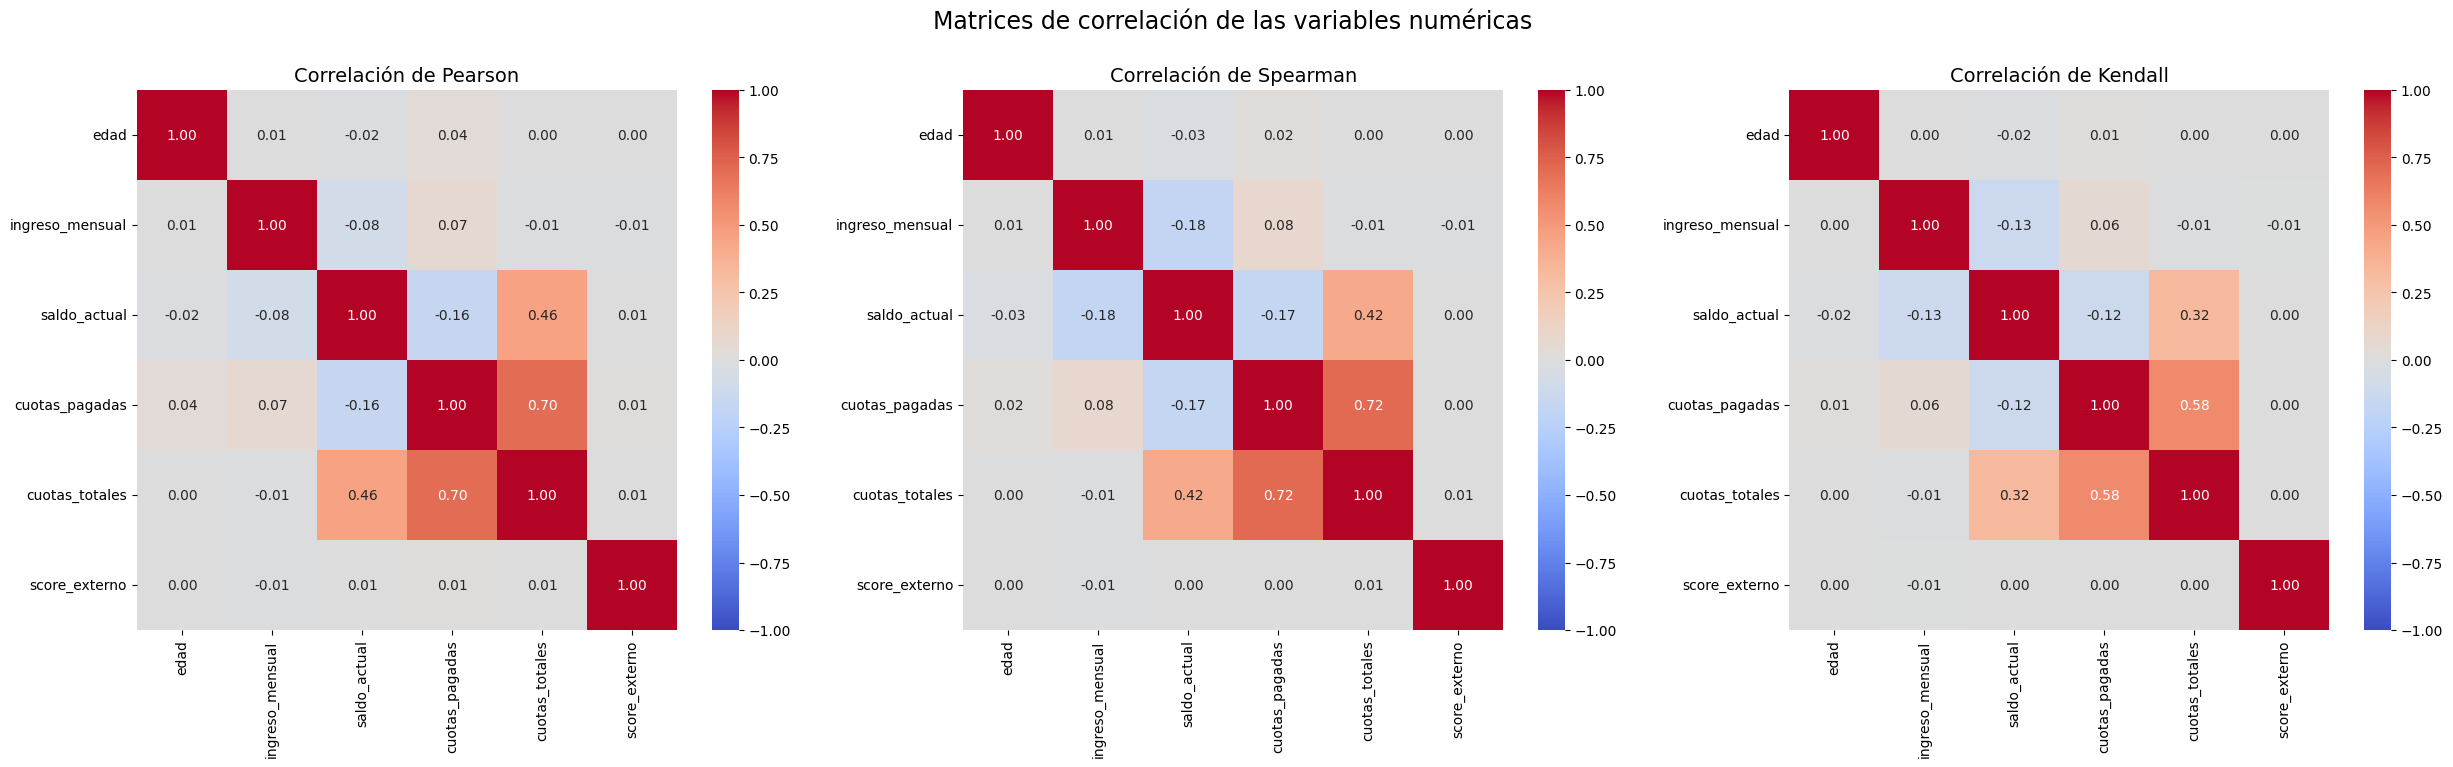

Imagen guardada correctamente en: solaris/output/correlaciones.png


In [20]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(25, 7)
)

sns.heatmap(
    correlacion_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0]
)

axes[0].set_title("Correlación de Pearson", fontsize=14)

sns.heatmap(
    correlacion_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title("Correlación de Spearman", fontsize=14)

sns.heatmap(
    correlacion_kendall,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[2]
)

axes[2].set_title("Correlación de Kendall", fontsize=14)

plt.suptitle(
    "Matrices de correlación de las variables numéricas",
    fontsize=17,
    y=1.03
)

plt.tight_layout()

ruta_correlaciones = os.path.join(
    carpeta_salida,
    "correlaciones.png"
)

plt.savefig(
    ruta_correlaciones,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Imagen guardada correctamente en: {ruta_correlaciones}")

In [21]:
def obtener_correlaciones_altas(
    matriz_correlacion,
    metodo,
    umbral=0.85
):
    """
    Extrae pares de variables cuya correlación absoluta
    sea superior al umbral establecido.
    """

    mascara_superior = np.triu(
        np.ones(matriz_correlacion.shape, dtype=bool),
        k=1
    )

    correlaciones = (
        matriz_correlacion
        .where(mascara_superior)
        .stack()
        .reset_index()
    )

    correlaciones.columns = [
        "variable_1",
        "variable_2",
        "correlacion"
    ]

    correlaciones["correlacion_absoluta"] = (
        correlaciones["correlacion"].abs()
    )

    correlaciones["metodo"] = metodo

    correlaciones_altas = correlaciones[
        correlaciones["correlacion_absoluta"] > umbral
    ]

    return correlaciones_altas.sort_values(
        by="correlacion_absoluta",
        ascending=False
    )

altas_pearson = obtener_correlaciones_altas(
    correlacion_pearson,
    metodo="Pearson",
    umbral=0.85
)

altas_spearman = obtener_correlaciones_altas(
    correlacion_spearman,
    metodo="Spearman",
    umbral=0.85
)

altas_kendall = obtener_correlaciones_altas(
    correlacion_kendall,
    metodo="Kendall",
    umbral=0.85
)

correlaciones_altas = pd.concat(
    [
        altas_pearson,
        altas_spearman,
        altas_kendall
    ],
    ignore_index=True
)

if correlaciones_altas.empty:
    print(
        "No se encontraron pares con correlación "
        "absoluta superior a 0.85."
    )
else:
    print(
        f"Se encontraron {len(correlaciones_altas)} "
        "correlaciones superiores a 0.85:"
    )

    display(correlaciones_altas)

No se encontraron pares con correlación absoluta superior a 0.85.


#PASO 5. Detección de outliers con IQR y Z-score

In [22]:
import os
import numpy as np
import pandas as pd

numericas = df.select_dtypes(include=[np.number])
resultados = []
resumen = []

for columna in numericas.columns:
    datos = df[columna]
    datos_validos = datos.dropna()

    # IQR
    q1 = datos_validos.quantile(0.25)
    q3 = datos_validos.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_iqr = (
        (datos < limite_inferior) |
        (datos > limite_superior)
    )

    # Z-score
    media = datos_validos.mean()
    desviacion = datos_validos.std(ddof=0)

    if desviacion == 0:
        z_score = pd.Series(0, index=df.index)
    else:
        z_score = (datos - media) / desviacion

    mascara_z = z_score.abs() > 3

    # Asimetría
    asimetria = datos_validos.skew()
    metodo_recomendado = "IQR" if abs(asimetria) > 2 else "Ambos métodos"

    # Registros detectados por al menos un método
    mascara_outlier = mascara_iqr | mascara_z

    for indice in df.index[mascara_outlier]:
        valor = df.loc[indice, columna]
        detectado_iqr = bool(mascara_iqr.loc[indice])
        detectado_z = bool(mascara_z.loc[indice])

        nombre = columna.lower()

        if nombre == "edad" and (valor < 0 or valor > 120):
            hipotesis = "Probable error: edad fuera de un rango válido."
        elif any(p in nombre for p in ["porcentaje", "porc", "pct"]) and (
            valor < 0 or valor > 100
        ):
            hipotesis = "Probable error: porcentaje fuera del rango 0-100."
        elif detectado_iqr and detectado_z:
            hipotesis = "Valor extremo severo; validar con la fuente original."
        elif abs(asimetria) > 2 and detectado_iqr:
            hipotesis = (
                "Posible valor extremo real debido a la distribución asimétrica; "
                "validar antes de eliminar."
            )
        else:
            hipotesis = (
                "Posible valor extremo; revisar con reglas de negocio."
            )

        resultados.append({
            "indice": indice,
            "id_cliente": (
                df.loc[indice, "id_cliente"]
                if "id_cliente" in df.columns
                else np.nan
            ),
            "variable": columna,
            "valor": valor,
            "outlier_IQR": detectado_iqr,
            "outlier_Zscore": detectado_z,
            "z_score": z_score.loc[indice],
            "limite_inferior_IQR": limite_inferior,
            "limite_superior_IQR": limite_superior,
            "skewness": asimetria,
            "metodo_recomendado": metodo_recomendado,
            "hipotesis": hipotesis
        })

    resumen.append({
        "variable": columna,
        "skewness": asimetria,
        "outliers_IQR": int(mascara_iqr.sum()),
        "outliers_Zscore": int(mascara_z.sum()),
        "outliers_totales": int(mascara_outlier.sum()),
        "metodo_recomendado": metodo_recomendado
    })

reporte_outliers = pd.DataFrame(resultados)
resumen_outliers = pd.DataFrame(resumen)

reporte_outliers.to_csv(
    os.path.join(carpeta_salida, "reporte_outliers.csv"),
    index=False,
    encoding="utf-8-sig"
)

display(resumen_outliers)
display(reporte_outliers.head(20))

print(f"Total de registros documentados: {len(reporte_outliers)}")
print("Archivo guardado: reporte_outliers.csv")

,variable,skewness,outliers_IQR,outliers_Zscore,outliers_totales,metodo_recomendado
0,edad,-0.281646,0,0,0,Ambos métodos
1,ingreso_mensual,1.366965,353,238,353,Ambos métodos
2,saldo_actual,2.323555,1018,306,1018,IQR
3,cuotas_pagadas,1.241219,586,34,586,Ambos métodos
4,cuotas_totales,0.441893,0,0,0,Ambos métodos
5,score_externo,-0.021761,0,0,0,Ambos métodos


,indice,id_cliente,variable,valor,outlier_IQR,outlier_Zscore,z_score,limite_inferior_IQR,limite_superior_IQR,skewness,metodo_recomendado,hipotesis
0,0,CLI-100000,ingreso_mensual,11525805,True,True,3.810666,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
1,30,CLI-100030,ingreso_mensual,9568213,True,False,2.999064,-5221229.625,8702049.375,1.366965,Ambos métodos,Posible valor extremo; revisar con reglas de n...
2,97,CLI-100097,ingreso_mensual,12051997,True,True,4.028821,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
3,101,CLI-100101,ingreso_mensual,9406922,True,False,2.932194,-5221229.625,8702049.375,1.366965,Ambos métodos,Posible valor extremo; revisar con reglas de n...
4,104,CLI-100104,ingreso_mensual,10644038,True,True,3.445092,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
5,123,CLI-100123,ingreso_mensual,8843857,True,False,2.698751,-5221229.625,8702049.375,1.366965,Ambos métodos,Posible valor extremo; revisar con reglas de n...
6,141,CLI-100141,ingreso_mensual,11571109,True,True,3.829449,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
7,198,CLI-100198,ingreso_mensual,9526075,True,False,2.981593,-5221229.625,8702049.375,1.366965,Ambos métodos,Posible valor extremo; revisar con reglas de n...
8,230,CLI-100230,ingreso_mensual,10616149,True,True,3.433530,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
9,252,CLI-100252,ingreso_mensual,11279944,True,True,3.708734,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...


Total de registros documentados: 1957
Archivo guardado: reporte_outliers.csv


# PASO 6. Análisis de valores faltantes

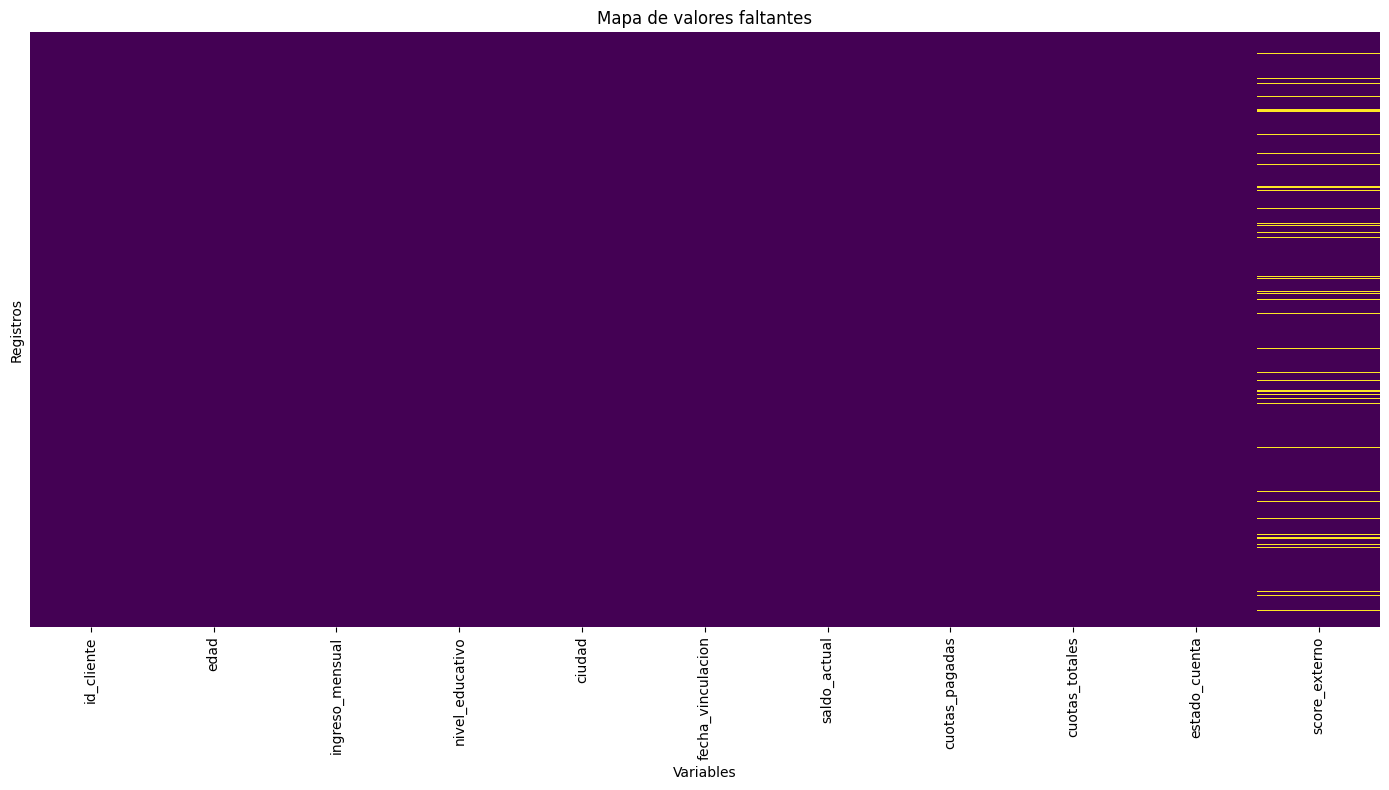

,cantidad_nulos,porcentaje_nulos
score_externo,1141,7.61
edad,0,0.00
id_cliente,0,0.00
ingreso_mensual,0,0.00
nivel_educativo,0,0.00
fecha_vinculacion,0,0.00
ciudad,0,0.00
saldo_actual,0,0.00
cuotas_pagadas,0,0.00
cuotas_totales,0,0.00


Filas con al menos un nulo: 1,141
Porcentaje de filas con nulos: 7.61%
Filas completas: 13,859
Archivo guardado: mapa_nulos.png


In [23]:
# Cantidad y porcentaje de nulos por columna
resumen_nulos = pd.DataFrame({
    "cantidad_nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().mean() * 100).round(2)
}).sort_values("cantidad_nulos", ascending=False)

# Filas con al menos un valor nulo
filas_con_nulos = df.isnull().any(axis=1)
cantidad_filas_con_nulos = filas_con_nulos.sum()
porcentaje_filas_con_nulos = filas_con_nulos.mean() * 100

# Mapa de calor
plt.figure(figsize=(14, 8))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap="viridis"
)

plt.title("Mapa de valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Registros")
plt.tight_layout()

plt.savefig(
    os.path.join(carpeta_salida, "mapa_nulos.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(resumen_nulos)

print(f"Filas con al menos un nulo: {cantidad_filas_con_nulos:,}")
print(f"Porcentaje de filas con nulos: {porcentaje_filas_con_nulos:.2f}%")
print(f"Filas completas: {(~filas_con_nulos).sum():,}")
print("Archivo guardado: mapa_nulos.png")

In [24]:
display(df[filas_con_nulos].head(20))

,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo
36,CLI-100036,32,0,Posgrado,CAL,2019-09-10,629040,13,18,Al día,NaN
38,CLI-100038,29,1817103,Secundaria,MANIZALES,2019-10-01,0,36,36,Cancelado,NaN
47,CLI-100047,63,5188948,Posgrado,SANTA MARTA,2015-03-28,0,24,24,Cancelado,NaN
52,CLI-100052,27,4514702,Técnico,"Bogotá, Colombia",2020-01-08,7541861,2,18,Moroso,NaN
57,CLI-100057,51,3242656,Técnico,IBAGUÉ,2017-09-14,2236043,6,12,Al día,NaN
63,CLI-100063,47,900000,Tecnólogo,CAL,2015-06-16,8341170,5,18,Moroso,NaN
66,CLI-100066,32,0,Secundaria,BUCARAMANGA,2023-08-23,2687425,1,12,Moroso,NaN
70,CLI-100070,34,2362663,Tecnólogo,CARTAGENA,2020-12-06,0,48,48,Cancelado,NaN
73,CLI-100073,57,0,Posgrado,Manizales,2023-09-06,5211882,6,18,Moroso,NaN
96,CLI-100096,3,0,Secundaria,Pereira,2018-01-11,26840511,3,48,Moroso,NaN


# PASO 7. Detección y análisis de duplicados

In [25]:
# Duplicados exactos
cantidad_duplicados_exactos = df.duplicated().sum()
duplicados_exactos = df[df.duplicated(keep=False)].sort_values(
    by=df.columns.tolist()
)

print(f"Duplicados exactos encontrados: {cantidad_duplicados_exactos}")
display(duplicados_exactos.head(20))

# IDs duplicados
if "id_cliente" in df.columns:
    cantidad_ids_duplicados = df["id_cliente"].duplicated().sum()

    ids_duplicados = df[
        df["id_cliente"].duplicated(keep=False)
    ].sort_values("id_cliente")

    print(f"IDs de cliente duplicados: {cantidad_ids_duplicados}")
    display(ids_duplicados.head(30))
else:
    print("No existe la columna id_cliente.")

# Resumen para documentar
resumen_duplicados = pd.DataFrame({
    "tipo": ["Duplicados exactos", "IDs duplicados"],
    "cantidad": [
        cantidad_duplicados_exactos,
        cantidad_ids_duplicados if "id_cliente" in df.columns else np.nan
    ]
})

display(resumen_duplicados)

Duplicados exactos encontrados: 0


,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo


IDs de cliente duplicados: 0


,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo


,tipo,cantidad
0,Duplicados exactos,0
1,IDs duplicados,0


# PASO 8. Verificación de tipos de dato y conversiones

In [26]:
import numpy as np
import pandas as pd

columnas_texto = df.select_dtypes(include=["object", "string"]).columns
resultados_tipos = []

# 1. Detectar columnas de fechas por el nombre
palabras_fecha = ["fecha", "date", "time"]

columnas_fecha = [
    columna for columna in columnas_texto
    if any(palabra in columna.lower() for palabra in palabras_fecha)
]

for columna in columnas_fecha:
    valores = df[columna]
    no_nulos = valores.notna()

    try:
        conversion = pd.to_datetime(
            valores,
            errors="coerce",
            format="mixed"
        )
    except TypeError:
        conversion = pd.to_datetime(
            valores,
            errors="coerce"
        )

    no_parseables = no_nulos & conversion.isna()
    total_evaluados = no_nulos.sum()
    exitosos = total_evaluados - no_parseables.sum()

    resultados_tipos.append({
        "columna": columna,
        "tipo_actual": str(df[columna].dtype),
        "tipo_sugerido": "datetime",
        "porcentaje_conversion_exitosa": (
            round(exitosos / total_evaluados * 100, 2)
            if total_evaluados > 0 else np.nan
        ),
        "valores_no_parseables": int(no_parseables.sum()),
        "ejemplos_problematicos": (
            df.loc[no_parseables, columna]
            .astype(str)
            .unique()[:5]
            .tolist()
        )
    })


# 2. Detectar columnas numéricas almacenadas como texto
for columna in columnas_texto:
    if columna in columnas_fecha:
        continue

    valores = df[columna]
    no_nulos = valores.notna()
    total_evaluados = no_nulos.sum()

    conversion = pd.to_numeric(
        valores.astype("string").str.strip(),
        errors="coerce"
    )

    exitosos = (conversion.notna() & no_nulos).sum()
    porcentaje_exito = (
        exitosos / total_evaluados * 100
        if total_evaluados > 0 else 0
    )

    if porcentaje_exito >= 90:
        no_parseables = no_nulos & conversion.isna()

        resultados_tipos.append({
            "columna": columna,
            "tipo_actual": str(df[columna].dtype),
            "tipo_sugerido": "numérico",
            "porcentaje_conversion_exitosa": round(porcentaje_exito, 2),
            "valores_no_parseables": int(no_parseables.sum()),
            "ejemplos_problematicos": (
                df.loc[no_parseables, columna]
                .astype(str)
                .unique()[:5]
                .tolist()
            )
        })


reporte_tipos = pd.DataFrame(resultados_tipos)

if reporte_tipos.empty:
    print("No se detectaron columnas con posibles tipos incorrectos.")
else:
    display(reporte_tipos)

reporte_tipos.to_csv(
    f"{carpeta_salida}/reporte_conversion_tipos.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivo guardado: reporte_conversion_tipos.csv")

,columna,tipo_actual,tipo_sugerido,porcentaje_conversion_exitosa,valores_no_parseables,ejemplos_problematicos
0,fecha_vinculacion,object,datetime,100.0,0,[]


Archivo guardado: reporte_conversion_tipos.csv


#PASO 9. Formulación de hipótesis analíticas iniciales

In [27]:
hipotesis = []

def agregar_hipotesis(id_, variables, hipotesis_, evidencia, relevancia, verificacion):
    hipotesis.append({
        "ID": id_,
        "variables": variables,
        "hipotesis": hipotesis_,
        "evidencia_EDA": evidencia,
        "relevancia_SOLARIS": relevancia,
        "como_verificar": verificacion
    })


# H1: carga de deuda e ingreso
ratio_deuda_ingreso = (
    df["saldo_actual"] /
    df["ingreso_mensual"].replace(0, np.nan)
)

r1 = ratio_deuda_ingreso.corr(
    df["score_externo"],
    method="spearman"
)

agregar_hipotesis(
    "H1",
    "saldo_actual, ingreso_mensual, score_externo",
    "Una mayor carga de deuda respecto al ingreso está asociada con un menor score externo.",
    f"Correlación Spearman entre deuda/ingreso y score externo: {r1:.3f}.",
    "La razón deuda/ingreso podría ser una característica útil para estimar el riesgo crediticio.",
    "Crear la variable deuda_ingreso, realizar un gráfico de dispersión y probarla en un modelo de riesgo."
)


# H2: avance en el pago
avance_pago = (
    df["cuotas_pagadas"] /
    df["cuotas_totales"].replace(0, np.nan)
)

r2 = avance_pago.corr(
    df["score_externo"],
    method="spearman"
)

agregar_hipotesis(
    "H2",
    "cuotas_pagadas, cuotas_totales, score_externo",
    "Los clientes con mayor proporción de cuotas pagadas presentan un mejor score externo.",
    f"Correlación Spearman entre avance de pago y score externo: {r2:.3f}.",
    "El porcentaje de avance puede representar el comportamiento histórico de pago del cliente.",
    "Comparar el avance de pago entre niveles de score y evaluar su importancia en modelos predictivos."
)


# H3: ingresos en cero con deuda activa
mascara_validos = (
    df["ingreso_mensual"].notna() &
    df["saldo_actual"].notna()
)

mascara_ingreso_cero = (
    (df["ingreso_mensual"] == 0) &
    (df["saldo_actual"] > 0) &
    mascara_validos
)

proporcion_ingreso_cero = (
    mascara_ingreso_cero.sum() / mascara_validos.sum()
)

agregar_hipotesis(
    "H3",
    "ingreso_mensual, saldo_actual",
    "Los ingresos iguales a cero en clientes con saldo activo pueden representar errores de captura o ingresos no reportados.",
    f"{proporcion_ingreso_cero:.2%} de los registros válidos tiene ingreso cero y saldo superior a cero.",
    "Tratar estos ceros como ingresos reales podría distorsionar indicadores como deuda/ingreso y el modelo de riesgo.",
    "Contrastar los registros con la fuente original y comparar su estado de cuenta y score con el resto de clientes."
)


# H4: edades atípicas
mascara_edad_invalida = (
    (df["edad"] < 18) |
    (df["edad"] > 100)
)

proporcion_edad_invalida = mascara_edad_invalida.mean()

agregar_hipotesis(
    "H4",
    "edad",
    "Las edades fuera del rango esperado corresponden principalmente a errores de calidad de datos.",
    f"{mascara_edad_invalida.sum()} registros ({proporcion_edad_invalida:.2%}) tienen edad menor a 18 o mayor a 100.",
    "Las edades incorrectas pueden generar relaciones falsas con el riesgo crediticio.",
    "Validar las edades con la fecha de nacimiento o la fuente original antes de imputar o eliminar."
)


# H5: diferencias del score según estado de cuenta
medianas_estado = (
    df.groupby("estado_cuenta")["score_externo"]
    .median()
    .dropna()
)

if len(medianas_estado) >= 2:
    diferencia_mediana = medianas_estado.max() - medianas_estado.min()

    agregar_hipotesis(
        "H5",
        "estado_cuenta, score_externo",
        "El score externo presenta diferencias entre los distintos estados de cuenta.",
        f"La diferencia entre la mayor y menor mediana del score por estado es {diferencia_mediana:.2f} puntos.",
        "El score externo podría ayudar a segmentar clientes y anticipar estados de mayor riesgo.",
        "Comparar las distribuciones mediante boxplots y aplicar una prueba de Kruskal-Wallis."
    )


hipotesis_iniciales = pd.DataFrame(hipotesis)

hipotesis_iniciales.to_csv(
    f"{carpeta_salida}/hipotesis_iniciales.csv",
    index=False,
    encoding="utf-8-sig"
)

display(hipotesis_iniciales)

print("Archivo guardado: hipotesis_iniciales.csv")

,ID,variables,hipotesis,evidencia_EDA,relevancia_SOLARIS,como_verificar
0,H1,"saldo_actual, ingreso_mensual, score_externo",Una mayor carga de deuda respecto al ingreso e...,Correlación Spearman entre deuda/ingreso y sco...,La razón deuda/ingreso podría ser una caracter...,"Crear la variable deuda_ingreso, realizar un g..."
1,H2,"cuotas_pagadas, cuotas_totales, score_externo",Los clientes con mayor proporción de cuotas pa...,Correlación Spearman entre avance de pago y sc...,El porcentaje de avance puede representar el c...,Comparar el avance de pago entre niveles de sc...
2,H3,"ingreso_mensual, saldo_actual",Los ingresos iguales a cero en clientes con sa...,31.00% de los registros válidos tiene ingreso ...,Tratar estos ceros como ingresos reales podría...,Contrastar los registros con la fuente origina...
3,H4,edad,Las edades fuera del rango esperado correspond...,847 registros (5.65%) tienen edad menor a 18 o...,Las edades incorrectas pueden generar relacion...,Validar las edades con la fecha de nacimiento ...
4,H5,"estado_cuenta, score_externo",El score externo presenta diferencias entre lo...,La diferencia entre la mayor y menor mediana d...,El score externo podría ayudar a segmentar cli...,Comparar las distribuciones mediante boxplots ...


Archivo guardado: hipotesis_iniciales.csv


# FEATURE STORE

## Paso 1: Divide el dataset ANTES de cualquier transformacion

In [28]:
from sklearn.model_selection import train_test_split

df_modelo = df[df["estado_cuenta"].isin(["Al día", "Moroso"])].copy()

y = df_modelo["estado_cuenta"].map({
    "Al día": 0,
    "Moroso": 1
})

X = df_modelo.drop(columns=["estado_cuenta"])

print("Nulos en y:", y.isna().sum())
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

print("\nProporción del target en TRAIN:")
print(y_train.value_counts(normalize=True))

print("\nProporción del target en TEST:")
print(y_test.value_counts(normalize=True))

Nulos en y: 0
Shape X_train: (9840, 10)
Shape X_test : (2460, 10)
Shape y_train: (9840,)
Shape y_test : (2460,)

Proporción del target en TRAIN:
estado_cuenta
0    0.853659
1    0.146341
Name: proportion, dtype: float64

Proporción del target en TEST:
estado_cuenta
0    0.853659
1    0.146341
Name: proportion, dtype: float64


### División inicial Train/Test

**Fecha del split:** 17 de agosto de 2026

Antes de realizar el análisis y las transformaciones correspondientes al
Módulo 2, se realizó la separación del conjunto de datos destinado al
modelado.

La variable objetivo se definió provisionalmente utilizando dos categorías
de `estado_cuenta`:

- `Al día` = 0
- `Moroso` = 1

La categoría `Cancelado` se excluyó provisionalmente, debido a que no se
cuenta todavía con suficiente información de negocio para asumir que
representa ausencia de mora.

Después de esta definición quedaron **12.300 registros utilizables para el
problema de clasificación**.

Se realizó una partición **80/20** mediante `train_test_split`, obteniendo:

- **Train:** 9.840 registros (80 %)
- **Test:** 2.460 registros (20 %)
- **random_state:** 42
- **Estratificación:** variable objetivo `y`

La proporción de clases obtenida fue:

| Conjunto | No moroso (0) | Moroso (1) |
|---|---:|---:|
| Train | 85,37 % | 14,63 % |
| Test | 85,37 % | 14,63 % |

Se utilizó `stratify=y` para conservar la distribución de la variable
objetivo en ambos conjuntos. Esto es especialmente importante debido al
desbalance observado entre las clases, donde aproximadamente el 14,63 %
de los registros corresponde a la clase morosa.

La división 80/20 permite conservar suficientes observaciones para el
desarrollo del pipeline, feature engineering y entrenamiento de los
modelos, mientras se reserva un conjunto independiente para evaluar
posteriormente su capacidad de generalización.

## Paso 2: Analiza los tipos de variables solo en X_train

In [29]:
# ============================================================
# REVISIÓN INICIAL DE X_train
# ============================================================

print("TIPOS DE DATOS")
print("=" * 50)
print(X_train.dtypes)

print("\nVALORES FALTANTES")
print("=" * 50)
print(X_train.isnull().sum())

print("\nCARDINALIDAD DE VARIABLES CATEGÓRICAS")
print("=" * 50)

categoricas = X_train.select_dtypes(include=["object", "category"]).columns

for col in categoricas:
    print(f"{col}: {X_train[col].nunique()} valores únicos")

TIPOS DE DATOS
id_cliente            object
edad                   int64
ingreso_mensual        int64
nivel_educativo       object
ciudad                object
fecha_vinculacion     object
saldo_actual           int64
cuotas_pagadas         int64
cuotas_totales         int64
score_externo        float64
dtype: object

VALORES FALTANTES
id_cliente             0
edad                   0
ingreso_mensual        0
nivel_educativo        0
ciudad                 0
fecha_vinculacion      0
saldo_actual           0
cuotas_pagadas         0
cuotas_totales         0
score_externo        846
dtype: int64

CARDINALIDAD DE VARIABLES CATEGÓRICAS
id_cliente: 9840 valores únicos
nivel_educativo: 6 valores únicos
ciudad: 73 valores únicos
fecha_vinculacion: 3538 valores únicos


### Decisiones iniciales de tratamiento de variables

Las decisiones de preparación se definieron exclusivamente a partir del
conjunto de entrenamiento (`X_train`). El conjunto de prueba (`X_test`)
permanece en cuarentena y no se utilizará para calcular estadísticas,
definir reglas de limpieza, imputar valores, seleccionar variables ni
realizar feature engineering.

| Variable | Tipo | Decisión de tratamiento |
|---|---|---|
| `id_cliente` | Categórica / identificador (`object`) | Presenta 9.840 valores únicos en 9.840 registros, por lo que funciona como identificador individual. Se conservará únicamente para trazabilidad, pero será excluido de las variables predictoras porque su valor no representa una característica generalizable del riesgo de mora. |
| `edad` | Numérica discreta (`int64`) | No presenta valores faltantes, pero durante la auditoría se identificaron edades fuera del rango plausible. Se validará el rango utilizando únicamente `X_train`. Los valores considerados inválidos se tratarán como datos anómalos y se evaluará su imputación en el pipeline, en lugar de eliminar automáticamente los registros. |
| `ingreso_mensual` | Numérica (`int64`) | No presenta nulos explícitos, pero se identificaron registros con ingreso igual a cero y saldo activo, por lo que el valor cero puede representar una anomalía o información no reportada. Se estudiará su tratamiento antes de construir la variable derivada deuda/ingreso y se evaluará crear un indicador de `ingreso_cero`. |
| `nivel_educativo` | Categórica nominal (`object`) | Presenta 6 categorías. Se revisará y estandarizará el formato de las categorías y posteriormente se aplicará codificación categórica, probablemente One-Hot Encoding. El codificador será ajustado únicamente con `X_train` y deberá permitir categorías desconocidas al aplicarse sobre nuevos datos. |
| `ciudad` | Categórica nominal (`object`) | Presenta 73 valores únicos. La auditoría mostró que existen diferentes representaciones de una misma ciudad, por lo que primero se normalizarán mayúsculas/minúsculas, tildes, espacios y abreviaturas. Después de reducir las categorías a ciudades consistentes se aplicará codificación categórica. |
| `fecha_vinculacion` | Fecha almacenada como texto (`object`) | Presenta 3.538 valores únicos, por lo que no será tratada como variable categórica. Se convertirá a `datetime` y se utilizará para construir una variable de antigüedad del distribuidor. Para calcularla deberá utilizarse una fecha de referencia fija y consistente con el momento de observación de los datos. La fecha original podrá excluirse posteriormente del modelo. |
| `saldo_actual` | Numérica (`int64`) | Se conservará inicialmente como predictor. Los valores extremos identificados durante la auditoría no se eliminarán automáticamente, ya que pueden corresponder a distribuidores legítimamente grandes. Se analizará su distribución en `X_train` y se evaluará si requiere una transformación para reducir asimetría. |
| `cuotas_pagadas` | Numérica discreta (`int64`) | Se conservará y se verificará su coherencia con `cuotas_totales`. También se utilizará para construir una variable de porcentaje de avance de pago. Los valores atípicos no se eliminarán automáticamente sin comprobar primero si representan errores o casos válidos. |
| `cuotas_totales` | Numérica discreta (`int64`) | Se conservará como predictor y se utilizará junto con `cuotas_pagadas` para construir el porcentaje de avance de pago. Antes de realizar la división se verificará que no existan valores iguales a cero para evitar divisiones indefinidas. |
| `score_externo` | Numérica continua (`float64`) | Presenta 846 valores faltantes en `X_train`, aproximadamente el 8,60 %. Se evaluará una estrategia de imputación, inicialmente mediante la mediana aprendida únicamente sobre `X_train`. También se considerará crear una variable indicadora que registre si el score estaba originalmente ausente. |

## Paso 3: Toma decisiones explicitas sobre variables numericas

In [30]:
import numpy as np
import pandas as pd

numericas = [
    "edad",
    "ingreso_mensual",
    "saldo_actual",
    "cuotas_pagadas",
    "cuotas_totales",
    "score_externo"
]

skewness = X_train[numericas].skew().sort_values(ascending=False)

print("SKEWNESS DE VARIABLES NUMÉRICAS")
print("=" * 50)
print(skewness)

SKEWNESS DE VARIABLES NUMÉRICAS
saldo_actual       2.274271
ingreso_mensual    1.482848
cuotas_pagadas     1.330420
cuotas_totales     0.447131
score_externo     -0.014933
edad              -0.305939
dtype: float64


### Decisiones de tratamiento de variables numéricas

Las decisiones se definieron utilizando exclusivamente el conjunto de
entrenamiento (`X_train`). Para determinar la necesidad de una transformación
logarítmica se calculó el skewness de cada variable numérica y se estableció
como criterio aplicar la transformación cuando el valor absoluto de skewness
fuera superior a 1.5.

Los resultados obtenidos fueron:

| Variable | Skewness | Escalamiento | Transformación | Imputación | Justificación |
|---|---:|---|---|---|---|
| `edad` | -0.306 | `StandardScaler` | No | Mediana si se generan nulos al tratar edades inválidas | Presenta baja asimetría y no requiere transformación logarítmica. Los valores no plausibles identificados previamente deberán tratarse antes del escalamiento. |
| `ingreso_mensual` | 1.483 | `RobustScaler` | No | Mediana si los ceros anómalos se tratan como faltantes | Aunque presenta asimetría positiva, no supera el umbral de 1.5 definido para aplicar log. Se utiliza `RobustScaler` por la presencia de valores extremos identificados durante la auditoría. |
| `saldo_actual` | 2.274 | `RobustScaler` | `log1p` | No requerida actualmente | Es la única variable con skewness absoluto superior a 1.5. Se aplicará `log1p` para disminuir la asimetría positiva y `RobustScaler` para reducir la influencia de valores extremos. |
| `cuotas_pagadas` | 1.330 | `RobustScaler` | No | No requerida | Su asimetría no supera el umbral de 1.5. Se utiliza `RobustScaler` debido a la presencia de valores atípicos identificados en la auditoría. |
| `cuotas_totales` | 0.447 | `StandardScaler` | No | No requerida | Presenta una distribución con asimetría moderada y no se identificaron problemas importantes de valores extremos. |
| `score_externo` | -0.015 | `StandardScaler` | No | Mediana | Su distribución es prácticamente simétrica, por lo que no necesita log. Presenta valores faltantes, que serán imputados mediante la mediana calculada únicamente sobre `X_train`. |

## Paso 4: Toma decisiones explicitas sobre variables categoricas


In [31]:
categoricas_modelo = ["nivel_educativo", "ciudad"]

for col in categoricas_modelo:
    print(f"\n{'='*60}")
    print(f"VARIABLE: {col}")
    print(f"{'='*60}")

    frecuencias = X_train[col].value_counts(normalize=True)

    print("\nFrecuencia relativa:")
    print(frecuencias)

    raras = frecuencias[frecuencias < 0.01]

    print("\nCategorías raras (< 1%):")
    if len(raras) == 0:
        print("No se encontraron categorías raras.")
    else:
        print(raras)

for col in categoricas_modelo:
    resumen = pd.DataFrame({
        "Frecuencia": X_train[col].value_counts(),
        "Proporcion": X_train[col].value_counts(normalize=True)
    })

    resumen["Porcentaje"] = (resumen["Proporcion"] * 100).round(2)

    print(f"\n--- {col} ---")
    display(resumen)


VARIABLE: nivel_educativo

Frecuencia relativa:
nivel_educativo
Secundaria       0.237602
Universitario    0.230691
Técnico          0.209248
Tecnólogo        0.179370
Posgrado         0.080589
Primaria         0.062500
Name: proportion, dtype: float64

Categorías raras (< 1%):
No se encontraron categorías raras.

VARIABLE: ciudad

Frecuencia relativa:
ciudad
PEREIRA               0.019207
Pereira, Risaralda    0.018191
MZL                   0.018089
Villavo               0.017886
ibague                0.017785
                        ...   
medellin              0.009756
Med.                  0.009654
Medellín              0.009045
Bogotá D.C.           0.008740
Medellin              0.008435
Name: proportion, Length: 73, dtype: float64

Categorías raras (< 1%):
ciudad
Barranquilla, Atlántico    0.009959
BOG                        0.009858
BOGOTÁ                     0.009858
medellin                   0.009756
Med.                       0.009654
Medellín                   0.009045
Bo

,Frecuencia,Proporcion,Porcentaje
nivel_educativo,,,
Secundaria,2338,0.237602,23.76
Universitario,2270,0.230691,23.07
Técnico,2059,0.209248,20.92
Tecnólogo,1765,0.179370,17.94
Posgrado,793,0.080589,8.06
Primaria,615,0.062500,6.25



--- ciudad ---


,Frecuencia,Proporcion,Porcentaje
ciudad,,,
PEREIRA,189,0.019207,1.92
"Pereira, Risaralda",179,0.018191,1.82
MZL,178,0.018089,1.81
Villavo,176,0.017886,1.79
ibague,175,0.017785,1.78
...,...,...,...
medellin,96,0.009756,0.98
Med.,95,0.009654,0.97
Medellín,89,0.009045,0.90


### Decisiones de tratamiento de variables categóricas

El análisis de las variables categóricas se realizó exclusivamente sobre
`X_train`. Se utilizó `value_counts(normalize=True)` para identificar
categorías con una frecuencia inferior al 1 %.

| Variable | Tipo | Cardinalidad | Codificación | Categorías raras | Decisión |
|---|---|---:|---|---|---|
| `nivel_educativo` | Ordinal | 6 | `OrdinalEncoder` | No se encontraron categorías < 1 % | Se conservarán las seis categorías y se codificarán respetando el orden Primaria → Secundaria → Técnico → Tecnólogo → Universitario → Posgrado. No se agruparán categorías en `Otro` debido a su baja cardinalidad y significado ordinal. |
| `ciudad` | Nominal | 73 etiquetas originales | `OneHotEncoder` | Se identificaron 8 etiquetas con frecuencia < 1 % antes de normalizar | No se agruparán directamente las etiquetas raras. Primero se estandarizarán mayúsculas, tildes, espacios y abreviaturas, debido a que varias categorías representan la misma ciudad. Después de obtener las ciudades canónicas se recalcularán las frecuencias y únicamente las ciudades reales que permanezcan por debajo del 1 % se agruparán en `Otro`. |
| `id_cliente` | Identificador | 9.840 | No aplica | No aplica | Se excluirá del conjunto de variables predictoras y se conservará únicamente para trazabilidad. |
| `fecha_vinculacion` | Fecha almacenada como texto | 3.538 | No aplica | No aplica | Se convertirá a `datetime` y posteriormente se utilizará para construir una variable numérica de antigüedad. |

## Paso 5: Diseña y crea las nuevas features (interacciones y ratios)


In [32]:
import numpy as np
import pandas as pd

# Trabajamos sobre una copia para no modificar X_train original
X_train_fe = X_train.copy()

print("Shape original:", X_train.shape)
print("Shape copia FE :", X_train_fe.shape)

Shape original: (9840, 10)
Shape copia FE : (9840, 10)


Validar coherencia de cuotas antes de construir ratios

In [33]:
# Registros donde se han pagado más cuotas que las cuotas totales
inconsistencia_cuotas = (
    X_train_fe["cuotas_pagadas"] > X_train_fe["cuotas_totales"]
)

print(
    "Registros con cuotas_pagadas > cuotas_totales:",
    inconsistencia_cuotas.sum()
)

print(
    "Porcentaje:",
    round(inconsistencia_cuotas.mean() * 100, 2),
    "%"
)

# Revisar algunos casos
X_train_fe.loc[
    inconsistencia_cuotas,
    ["cuotas_pagadas", "cuotas_totales", "saldo_actual"]
].head(20)

Registros con cuotas_pagadas > cuotas_totales: 178
Porcentaje: 1.81 %


,cuotas_pagadas,cuotas_totales,saldo_actual
7878,10,6,514836
1283,23,18,2856284
267,17,12,4421748
8610,42,36,8024434
5587,50,48,4867675
13581,8,6,232403
2859,25,18,6966981
3284,50,48,29267757
5518,31,24,976150
950,52,48,3029951


In [34]:
diferencia_cuotas = (
    X_train_fe.loc[
        inconsistencia_cuotas,
        "cuotas_pagadas"
    ]
    -
    X_train_fe.loc[
        inconsistencia_cuotas,
        "cuotas_totales"
    ]
)

print("Diferencia entre cuotas pagadas y totales:")
print(diferencia_cuotas.describe())

Diferencia entre cuotas pagadas y totales:
count    178.000000
mean       4.348315
std        2.227720
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max        8.000000
dtype: float64


In [35]:
print(
    "Ingresos mensuales iguales a 0:",
    (X_train_fe["ingreso_mensual"] == 0).sum()
)

print(
    "Cuotas totales iguales a 0:",
    (X_train_fe["cuotas_totales"] == 0).sum()
)

print(
    "Saldo actual igual a 0:",
    (X_train_fe["saldo_actual"] == 0).sum()
)

Ingresos mensuales iguales a 0: 3719
Cuotas totales iguales a 0: 0
Saldo actual igual a 0: 0


Feature 1: ratio_deuda_ingreso

In [36]:
X_train_fe["ratio_deuda_ingreso"] = (
    X_train_fe["saldo_actual"] /
    (X_train_fe["ingreso_mensual"] + 1)
)

Representa:
saldo actual/
ingreso mensual+1

Un valor alto indica que la deuda es grande en relación con el ingreso reportado.

Feature 2: ingreso_cero

In [37]:
X_train_fe["ingreso_cero"] = (
    X_train_fe["ingreso_mensual"] == 0
).astype(int)

0 = existe ingreso reportado
1 = ingreso_mensual está registrado como 0

Feature 3: inconsistencia_cuotas

In [38]:
X_train_fe["inconsistencia_cuotas"] = (
    X_train_fe["cuotas_pagadas"] >
    X_train_fe["cuotas_totales"]
).astype(int)

0 = cuotas coherentes
1 = cuotas_pagadas > cuotas_totales


Feature 4: avance_pago

In [39]:
X_train_fe["avance_pago"] = np.where(
    X_train_fe["inconsistencia_cuotas"] == 0,

    X_train_fe["cuotas_pagadas"] /
    (X_train_fe["cuotas_totales"] + 1),

    np.nan
)

Feature 5: cuotas_pendientes

In [40]:
X_train_fe["cuotas_pendientes"] = np.where(
    X_train_fe["inconsistencia_cuotas"] == 0,

    X_train_fe["cuotas_totales"] -
    X_train_fe["cuotas_pagadas"],

    np.nan
)

Feature 6: saldo_por_cuota_pendiente

In [41]:
X_train_fe["saldo_por_cuota_pendiente"] = (
    X_train_fe["saldo_actual"] /
    (X_train_fe["cuotas_pendientes"] + 1)
)

Revisar las nuevas features

In [42]:
nuevas_features = [
    "ratio_deuda_ingreso",
    "ingreso_cero",
    "inconsistencia_cuotas",
    "avance_pago",
    "cuotas_pendientes",
    "saldo_por_cuota_pendiente"
]

X_train_fe[nuevas_features].head(50)

,ratio_deuda_ingreso,ingreso_cero,inconsistencia_cuotas,avance_pago,cuotas_pendientes,saldo_por_cuota_pendiente
7679,5.116287e+06,1,0,0.315789,12.0,393560.538462
2091,1.484028e+06,1,0,0.480000,12.0,114156.000000
3526,2.881350e+06,1,0,0.142857,5.0,480225.000000
8299,8.980082e+06,1,0,0.510204,23.0,374170.083333
2842,1.748498e+00,0,0,0.428571,27.0,296457.464286
13534,1.157500e-01,0,0,0.571429,2.0,207597.666667
1515,2.217936e+06,1,0,0.560000,10.0,201630.545455
9947,1.856072e+00,0,0,0.408163,28.0,245142.896552
1950,8.509052e-01,0,0,0.157895,15.0,286559.625000
11269,1.318684e+06,1,0,0.729730,9.0,131868.400000


In [43]:
print("VALORES FALTANTES EN LAS NUEVAS FEATURES")
print("=" * 55)

print(
    X_train_fe[nuevas_features]
    .isnull()
    .sum()
)

VALORES FALTANTES EN LAS NUEVAS FEATURES
ratio_deuda_ingreso            0
ingreso_cero                   0
inconsistencia_cuotas          0
avance_pago                  178
cuotas_pendientes            178
saldo_por_cuota_pendiente    178
dtype: int64


In [44]:
print("VALORES INFINITOS EN LAS NUEVAS FEATURES")
print("=" * 55)

for col in nuevas_features:
    if pd.api.types.is_numeric_dtype(X_train_fe[col]):
        cantidad_inf = np.isinf(X_train_fe[col]).sum()
        print(f"{col}: {cantidad_inf}")

VALORES INFINITOS EN LAS NUEVAS FEATURES
ratio_deuda_ingreso: 0
ingreso_cero: 0
inconsistencia_cuotas: 0
avance_pago: 0
cuotas_pendientes: 0
saldo_por_cuota_pendiente: 0


In [45]:
X_train_fe[nuevas_features].describe().T

,count,mean,std,min,25%,50%,75%,max
ratio_deuda_ingreso,9840.0,1.517044e+06,3.220095e+06,0.005709,0.665760,2.455410,1.617132e+06,2.995746e+07
ingreso_cero,9840.0,3.779472e-01,4.848990e-01,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
inconsistencia_cuotas,9840.0,1.808943e-02,1.332817e-01,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
avance_pago,9662.0,4.208116e-01,2.249102e-01,0.000000,0.230769,0.405405,6.122449e-01,8.775510e-01
cuotas_pendientes,9662.0,1.296543e+01,9.940806e+00,1.000000,5.000000,10.000000,1.800000e+01,4.800000e+01
saldo_por_cuota_pendiente,9662.0,2.575277e+05,1.224569e+05,40559.500000,160190.616099,246509.558696,3.364205e+05,6.813057e+05


In [46]:
print(
    "Avance de pago mínimo:",
    X_train_fe["avance_pago"].min()
)

print(
    "Avance de pago máximo:",
    X_train_fe["avance_pago"].max()
)

Avance de pago mínimo: 0.0
Avance de pago máximo: 0.8775510204081632


In [47]:
print(
    "Cuotas pendientes negativas:",
    (X_train_fe["cuotas_pendientes"] < 0).sum()
)

Cuotas pendientes negativas: 0


### Creación de features

El feature engineering se realizó exclusivamente sobre `X_train`,
manteniendo el conjunto de prueba en cuarentena.

Las nuevas variables fueron diseñadas a partir del conocimiento del
problema de riesgo crediticio de FrescaMar y de los hallazgos obtenidos
durante el Discovery.

Antes de construir las variables relacionadas con cuotas se verificó la
consistencia entre `cuotas_pagadas` y `cuotas_totales`. Se encontraron
178 registros en los que las cuotas pagadas superan las cuotas totales.
Debido a que no existe suficiente información para determinar cuál de
los dos valores es incorrecto, estos registros no fueron corregidos ni
eliminados arbitrariamente.

En su lugar, se creó una variable indicadora denominada
`inconsistencia_cuotas`. Las features dependientes de la relación entre
cuotas se dejaron como valores faltantes para dichos registros, de modo
que su tratamiento pueda realizarse posteriormente dentro del pipeline.

| Feature | Fórmula | Razón de negocio |
|---|---|---|
| `ratio_deuda_ingreso` | `saldo_actual / (ingreso_mensual + 1)` | Mide la deuda actual en relación con el ingreso reportado. Una relación elevada puede representar una mayor presión financiera. |
| `ingreso_cero` | `1 si ingreso_mensual == 0; 0 en otro caso` | Conserva la señal asociada a los registros cuyo ingreso está reportado como cero, anomalía relevante identificada durante el Discovery. |
| `inconsistencia_cuotas` | `1 si cuotas_pagadas > cuotas_totales; 0 en otro caso` | Permite conservar explícitamente la señal de inconsistencia encontrada entre las variables de comportamiento de pago. |
| `avance_pago` | `cuotas_pagadas / (cuotas_totales + 1)` | Representa el nivel de avance del distribuidor dentro de su compromiso de pago. Solo se calcula cuando las cuotas originales son coherentes. |
| `cuotas_pendientes` | `cuotas_totales - cuotas_pagadas` | Representa la cantidad de obligaciones periódicas que todavía quedan pendientes. Para registros inconsistentes se considera como dato faltante. |
| `saldo_por_cuota_pendiente` | `saldo_actual / (cuotas_pendientes + 1)` | Relaciona la exposición monetaria actual con la cantidad de cuotas que todavía faltan por pagar. |

Estas variables se consideran features candidatas. Su utilidad definitiva
no se asumirá únicamente por su interpretación de negocio, sino que será
evaluada posteriormente mediante el desempeño de los modelos fuera de
muestra.

## Paso 6: Construye el ColumnTransformer con todas las decisiones

In [48]:
import numpy as np
import pandas as pd

# Features numéricas nuevas que NO son indicadores binarios
nuevas_numericas = [
    "ratio_deuda_ingreso",
    "avance_pago",
    "cuotas_pendientes",
    "saldo_por_cuota_pendiente"
]

print("SKEWNESS DE LAS NUEVAS FEATURES")
print("=" * 50)

skew_nuevas = X_train_fe[nuevas_numericas].skew()

print(skew_nuevas)

SKEWNESS DE LAS NUEVAS FEATURES
ratio_deuda_ingreso          3.386827
avance_pago                  0.125458
cuotas_pendientes            1.122812
saldo_por_cuota_pendiente    0.692411
dtype: float64


In [49]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)

# ============================================================
# 1. LISTAS DE VARIABLES
# ============================================================

# Skewness > 1.5
cols_log_scale = [
    "saldo_actual",
    "ratio_deuda_ingreso"
]

# Variables numéricas sin transformación log
cols_std_scale = [
    "edad",
    "ingreso_mensual",
    "cuotas_pagadas",
    "cuotas_totales",
    "score_externo",
    "avance_pago",
    "cuotas_pendientes",
    "saldo_por_cuota_pendiente",
    "ingreso_cero",
    "inconsistencia_cuotas"
]

# Variable nominal
cols_one_hot = [
    "ciudad"
]

# Variable ordinal
cols_ordinal = [
    "nivel_educativo"
]

# Orden de nivel educativo
orden_educativo = [
    "Primaria",
    "Secundaria",
    "Técnico",
    "Tecnólogo",
    "Universitario",
    "Posgrado"
]


# ============================================================
# 2. PIPELINES
# ============================================================

# Numéricas con alta asimetría
pipeline_log = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

# Numéricas sin log
pipeline_std = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categóricas nominales
pipeline_ohe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Categóricas ordinales
pipeline_ordinal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=[orden_educativo],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])


# ============================================================
# 3. COLUMNTRANSFORMER
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("log", pipeline_log, cols_log_scale),
        ("std", pipeline_std, cols_std_scale),
        ("ohe", pipeline_ohe, cols_one_hot),
        ("ord", pipeline_ordinal, cols_ordinal)
    ],
    remainder="drop"
)

preprocessor

ColumnTransformer(transformers=[('log',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['saldo_actual', 'ratio_deuda_ingreso']),
                                ('std',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ciudad']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Primaria',
                                                                              'Secundaria',
                                                                              'Técnico',
                                                                              'Tecnólogo',
                                                                              'Universitario',
                                                                              'Posgrado']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['nivel_educativo'])])

### Construcción del `ColumnTransformer`

A partir de las decisiones tomadas en los pasos anteriores, se construyó un
`ColumnTransformer` para integrar en un único proceso las transformaciones
necesarias para las variables numéricas y categóricas.

En este paso únicamente se define la estructura del preprocesamiento.
El ajuste del `ColumnTransformer` se realizará posteriormente y exclusivamente
sobre el conjunto de entrenamiento, evitando que el conjunto de prueba participe
en el aprendizaje de parámetros.

### Selección de variables según skewness

Para determinar qué variables requieren transformación logarítmica se utilizó
el criterio de aplicar `log1p` cuando el valor absoluto del skewness es superior
a 1.5.

En las variables originales, `saldo_actual` presentó un skewness de **2.274**.
Después del feature engineering también se evaluó el skewness de las nuevas
variables:

| Feature nueva | Skewness |
|---|---:|
| `ratio_deuda_ingreso` | 3.387 |
| `avance_pago` | 0.125 |
| `cuotas_pendientes` | 1.123 |
| `saldo_por_cuota_pendiente` | 0.692 |

Por lo tanto, las variables seleccionadas para transformación logarítmica son:

- `saldo_actual`
- `ratio_deuda_ingreso`

Las demás variables numéricas presentan un skewness absoluto inferior a 1.5,
por lo que no requieren transformación logarítmica.

### Familias de transformación

Se definieron cuatro grupos de variables:

| Familia | Variables | Pipeline aplicado |
|---|---|---|
| `cols_log_scale` | `saldo_actual`, `ratio_deuda_ingreso` | Imputación por mediana → `log1p` → `StandardScaler` |
| `cols_std_scale` | `edad`, `ingreso_mensual`, `cuotas_pagadas`, `cuotas_totales`, `score_externo`, `avance_pago`, `cuotas_pendientes`, `saldo_por_cuota_pendiente`, `ingreso_cero`, `inconsistencia_cuotas` | Imputación por mediana → `StandardScaler` |
| `cols_one_hot` | `ciudad` | Imputación por moda → `OneHotEncoder(handle_unknown='ignore')` |
| `cols_ordinal` | `nivel_educativo` | Imputación por moda → `OrdinalEncoder` |

### Pipeline de variables con alta asimetría

Para `saldo_actual` y `ratio_deuda_ingreso` se definió el siguiente pipeline:

`SimpleImputer(strategy='median') → FunctionTransformer(np.log1p) → StandardScaler`

Primero se imputarán posibles valores faltantes con la mediana. Posteriormente
se aplicará `log1p` para reducir la asimetría positiva y finalmente
`StandardScaler` para estandarizar las variables.

Los parámetros necesarios para estas transformaciones serán aprendidos
exclusivamente a partir del conjunto de entrenamiento en el siguiente paso.

### Pipeline de variables numéricas estándar

Las variables numéricas que no superan el umbral de skewness de 1.5 se
procesarán mediante:

`SimpleImputer(strategy='median') → StandardScaler`

La imputación por mediana permitirá manejar tanto los faltantes originales,
como los presentes en `score_externo`, como los valores faltantes generados
durante el feature engineering en las variables relacionadas con las
inconsistencias de cuotas.

### Pipeline de variables categóricas nominales

`ciudad` se considera una variable nominal, ya que no existe un orden natural
entre sus categorías. Por esta razón se definió el siguiente pipeline:

`SimpleImputer(strategy='most_frequent') → OneHotEncoder(handle_unknown='ignore')`

El parámetro `handle_unknown='ignore'` permitirá procesar posteriormente
categorías que no hayan aparecido en el conjunto de entrenamiento sin generar
errores.

Debido a las inconsistencias de formato identificadas previamente en `ciudad`,
la normalización y unificación de sus distintas representaciones se considera
una etapa necesaria antes de su codificación definitiva.

### Pipeline de la variable categórica ordinal

`nivel_educativo` presenta un orden natural, por lo que se utiliza
`OrdinalEncoder` con la siguiente jerarquía:

`Primaria → Secundaria → Técnico → Tecnólogo → Universitario → Posgrado`

El pipeline definido es:

`SimpleImputer(strategy='most_frequent') → OrdinalEncoder`

También se configuró un valor especial para categorías desconocidas mediante
`unknown_value=-1`, lo que permitirá procesar observaciones futuras con niveles
no encontrados durante el entrenamiento.

### Exclusión de variables

El `ColumnTransformer` utiliza `remainder='drop'`, por lo que cualquier variable
que no se encuentre explícitamente incluida en las listas definidas será
descartada de la matriz final utilizada por el modelo.

De esta forma, `id_cliente` y `fecha_vinculacion` no entran directamente al
modelo. `id_cliente` se conserva únicamente como identificador para trazabilidad,
mientras que `fecha_vinculacion` no se utiliza directamente debido a que requiere
una transformación específica para generar una variable numérica de antigüedad.

### Prevención de fuga de información

En este paso el `ColumnTransformer` únicamente se construye y se dejan
especificadas todas las transformaciones que deberán realizarse. Todavía no
se ejecuta `fit`, `fit_transform` ni se calculan parámetros a partir de los
datos.

El ajuste del preprocesador se realizará en el Paso 7 exclusivamente con
`X_train_fe`. De esta manera, las medianas utilizadas para imputación, las
medias y desviaciones estándar utilizadas por `StandardScaler` y las categorías
aprendidas por los codificadores provendrán únicamente del conjunto de
entrenamiento.

Posteriormente, esas transformaciones ya aprendidas se aplicarán al conjunto
de prueba utilizando únicamente `transform`, sin ejecutar `fit` sobre `X_test`.

## Paso 7: Ajusta el preprocesador SOLO con X_train

In [50]:
def crear_features(X):
    X_fe = X.copy()

    # Ratio deuda / ingreso
    X_fe["ratio_deuda_ingreso"] = (
        X_fe["saldo_actual"] /
        (X_fe["ingreso_mensual"] + 1)
    )

    # Indicador de ingreso cero
    X_fe["ingreso_cero"] = (
        X_fe["ingreso_mensual"] == 0
    ).astype(int)

    # Indicador de inconsistencia de cuotas
    X_fe["inconsistencia_cuotas"] = (
        X_fe["cuotas_pagadas"] > X_fe["cuotas_totales"]
    ).astype(int)

    # Avance de pago
    X_fe["avance_pago"] = np.where(
        X_fe["inconsistencia_cuotas"] == 0,
        X_fe["cuotas_pagadas"] / (X_fe["cuotas_totales"] + 1),
        np.nan
    )

    # Cuotas pendientes
    X_fe["cuotas_pendientes"] = np.where(
        X_fe["inconsistencia_cuotas"] == 0,
        X_fe["cuotas_totales"] - X_fe["cuotas_pagadas"],
        np.nan
    )

    # Saldo por cuota pendiente
    X_fe["saldo_por_cuota_pendiente"] = (
        X_fe["saldo_actual"] /
        (X_fe["cuotas_pendientes"] + 1)
    )

    return X_fe


X_train_fe = crear_features(X_train)
X_test_fe = crear_features(X_test)

print("X_train_fe:", X_train_fe.shape)
print("X_test_fe :", X_test_fe.shape)

X_train_fe: (9840, 16)
X_test_fe : (2460, 16)


In [51]:
# ============================================================
# PASO 7 - AJUSTAR EL PREPROCESADOR SOLO CON TRAIN
# ============================================================

# 1. FIT únicamente sobre TRAIN
preprocessor.fit(X_train_fe)

# 2. Transformar TRAIN con lo aprendido
X_train_proc = preprocessor.transform(X_train_fe)

# 3. Transformar TEST con lo aprendido
# NUNCA hacer fit sobre test
X_test_proc = preprocessor.transform(X_test_fe)


# ============================================================
# VERIFICAR SHAPES
# ============================================================

print("SHAPES")
print("=" * 50)
print("X_train original :", X_train.shape)
print("X_test original  :", X_test.shape)
print("X_train procesado:", X_train_proc.shape)
print("X_test procesado :", X_test_proc.shape)


# ============================================================
# VERIFICAR NaN
# ============================================================

# Si sklearn devuelve matrices sparse, convertirlas solo
# para hacer esta comprobación
train_check = (
    X_train_proc.toarray()
    if hasattr(X_train_proc, "toarray")
    else X_train_proc
)

test_check = (
    X_test_proc.toarray()
    if hasattr(X_test_proc, "toarray")
    else X_test_proc
)

print("\n¿HAY NaN?")
print("=" * 50)
print("Train:", np.isnan(train_check).any())
print("Test :", np.isnan(test_check).any())

SHAPES
X_train original : (9840, 10)
X_test original  : (2460, 10)
X_train procesado: (9840, 86)
X_test procesado : (2460, 86)

¿HAY NaN?
Train: False
Test : False


### Ajuste del preprocesador exclusivamente con `X_train`

Una vez construido el `ColumnTransformer`, el preprocesador se ajustó
exclusivamente utilizando el conjunto de entrenamiento.

Debido a que en el Paso 5 se crearon nuevas features, se trabajó con
`X_train_fe` y `X_test_fe`, los cuales contienen las mismas variables derivadas.
Estas transformaciones fueron definidas previamente y se aplicaron de manera
consistente a ambos conjuntos.

La línea principal de este paso fue:

`preprocessor.fit(X_train_fe)`

Este ajuste permite que el preprocesador aprenda únicamente a partir del
conjunto de entrenamiento los parámetros necesarios para las transformaciones,
como las medianas utilizadas para imputación, las medias y desviaciones estándar
de `StandardScaler` y las categorías utilizadas por los codificadores.

Posteriormente, se aplicaron las transformaciones aprendidas a ambos conjuntos:

`X_train_proc = preprocessor.transform(X_train_fe)`

`X_test_proc = preprocessor.transform(X_test_fe)`

Es importante resaltar que sobre el conjunto de prueba únicamente se ejecutó
`transform` y nunca `fit`, evitando así fuga de información.

### Verificación de dimensiones

Después del preprocesamiento se obtuvieron las siguientes dimensiones:

| Conjunto | Antes del preprocesamiento | Después del preprocesamiento |
|---|---:|---:|
| `X_train` | 9.840 filas × 10 columnas | 9.840 filas × 86 variables |
| `X_test` | 2.460 filas × 10 columnas | 2.460 filas × 86 variables |

El número de observaciones se mantuvo sin cambios. El aumento de columnas se
debe principalmente a la codificación `One-Hot` de las variables categóricas
y a la incorporación de las features creadas durante el feature engineering.

Además, tanto `X_train_proc` como `X_test_proc` presentan exactamente
**86 variables**, lo que confirma que el mismo preprocesador produjo una
estructura compatible para entrenamiento y evaluación.

### Verificación de valores faltantes

Se comprobó la presencia de valores `NaN` después de aplicar todas las
transformaciones:

- `X_train_proc`: **False**
- `X_test_proc`: **False**

Por lo tanto, ninguno de los dos conjuntos procesados contiene valores
faltantes. Esto confirma que las estrategias de imputación definidas dentro
del `ColumnTransformer` procesaron correctamente los datos antes del
entrenamiento del modelo.

En conclusión, el preprocesador fue aprendido únicamente con información de
entrenamiento y posteriormente aplicado al conjunto de prueba sin reajustarlo.
Los dos conjuntos quedaron con la misma cantidad de variables y sin valores
faltantes, por lo que están listos para utilizarse en la etapa de modelado.

## Paso 8: Obten los nombres de las features transformadas


In [52]:
# ============================================================
# PASO 8 - RECUPERAR NOMBRES DE LAS FEATURES TRANSFORMADAS
# ============================================================

# 1. Nombres de variables con log + StandardScaler
nombres_log = [
    f"log_{col}" for col in cols_log_scale
]

# 2. Nombres de variables con StandardScaler
nombres_std = [
    f"std_{col}" for col in cols_std_scale
]

# 3. Recuperar el OneHotEncoder YA AJUSTADO dentro del preprocessor
ohe_ajustado = (
    preprocessor
    .named_transformers_["ohe"]
    .named_steps["onehot"]
)

# Nombres generados por One-Hot Encoding
nombres_ohe = ohe_ajustado.get_feature_names_out(
    cols_one_hot
).tolist()

# 4. Nombres de variables ordinales
nombres_ord = [
    f"ord_{col}" for col in cols_ordinal
]

# 5. Combinar todos los nombres en el mismo orden del ColumnTransformer
feature_names = (
    nombres_log
    + nombres_std
    + nombres_ohe
    + nombres_ord
)

# ============================================================
# VERIFICACIÓN
# ============================================================

print("Total de features:", len(feature_names))
print("\nPrimeras 10 features:")

for nombre in feature_names[:30]:
    print(nombre)

print("\nColumnas en X_train_proc:", X_train_proc.shape[1])
print(
    "¿Coinciden los nombres con las columnas?:",
    len(feature_names) == X_train_proc.shape[1]
)

Total de features: 86

Primeras 10 features:
log_saldo_actual
log_ratio_deuda_ingreso
std_edad
std_ingreso_mensual
std_cuotas_pagadas
std_cuotas_totales
std_score_externo
std_avance_pago
std_cuotas_pendientes
std_saldo_por_cuota_pendiente
std_ingreso_cero
std_inconsistencia_cuotas
ciudad_B/manga
ciudad_B/quilla
ciudad_BAQ
ciudad_BARRANQUILLA
ciudad_BGA
ciudad_BOG
ciudad_BOGOTÁ
ciudad_BUCARAMANGA
ciudad_Barranqilla
ciudad_Barranquilla
ciudad_Barranquilla, Atlántico
ciudad_Bogota
ciudad_Bogotá
ciudad_Bogotá D.C.
ciudad_Bogotá, Colombia
ciudad_Bta
ciudad_Bucaramanga
ciudad_Bucaramanga, Santander

Columnas en X_train_proc: 86
¿Coinciden los nombres con las columnas?: True


### Recuperación de los nombres de las features transformadas

Después de aplicar el `ColumnTransformer`, los conjuntos procesados se
encuentran representados como matrices numéricas y las columnas dejan de
conservar directamente sus nombres originales. Recuperar estos nombres es
importante para poder interpretar posteriormente el modelo y relacionar sus
coeficientes o importancias con las variables de origen.

Los nombres se reconstruyeron respetando el mismo orden utilizado dentro del
`ColumnTransformer`.

Para las variables sometidas a transformación logarítmica se utilizó el
prefijo `log_`, mientras que las variables estandarizadas utilizaron el
prefijo `std_`.

En el caso de `ciudad`, los nombres de las variables creadas por
`OneHotEncoder` se recuperaron directamente desde el encoder ya ajustado
mediante `get_feature_names_out()`. Esto permite identificar cada columna
binaria con la categoría que representa.

Finalmente, las variables procesadas mediante `OrdinalEncoder` se
identificaron con el prefijo `ord_`.

Después de combinar todos los nombres se obtuvieron **86 features
transformadas**, el mismo número de columnas presentes en `X_train_proc` y
`X_test_proc`.

También se verificó que la cantidad de nombres recuperados coincidiera
exactamente con el número de columnas de la matriz procesada. Esta
correspondencia permitirá interpretar correctamente las variables utilizadas
por los modelos en las siguientes etapas.

## Paso 9: Exporta el pipeline a un archivo .py reutilizable

In [53]:
import os

os.makedirs("feature_store", exist_ok=True)

print("Carpeta feature_store lista.")

Carpeta feature_store lista.


In [54]:
%%writefile feature_store/feature_store_v1.py

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)


# ============================================================
# CONFIGURACIÓN
# ============================================================

# Variables con |skewness| > 1.5
COLS_LOG_SCALE = [
    "saldo_actual",
    "ratio_deuda_ingreso"
]

# Variables numéricas sin transformación logarítmica
COLS_STD_SCALE = [
    "edad",
    "ingreso_mensual",
    "cuotas_pagadas",
    "cuotas_totales",
    "score_externo",
    "avance_pago",
    "cuotas_pendientes",
    "saldo_por_cuota_pendiente",
    "ingreso_cero",
    "inconsistencia_cuotas"
]

# Variable categórica nominal
COLS_ONE_HOT = [
    "ciudad"
]

# Variable categórica ordinal
COLS_ORDINAL = [
    "nivel_educativo"
]

# Orden definido para nivel educativo
ORDEN_EDUCATIVO = [
    "Primaria",
    "Secundaria",
    "Técnico",
    "Tecnólogo",
    "Universitario",
    "Posgrado"
]


# ============================================================
# FEATURE ENGINEERING
# ============================================================

def crear_features(df):
    """
    Crea las features derivadas utilizadas en el Proyecto SOLARIS.

    La función no modifica el DataFrame original.
    Retorna una copia con las nuevas variables.
    """

    X = df.copy()

    # 1. Relación entre deuda actual e ingreso mensual
    X["ratio_deuda_ingreso"] = (
        X["saldo_actual"] /
        (X["ingreso_mensual"] + 1)
    )

    # 2. Indicador de ingreso reportado como cero
    X["ingreso_cero"] = (
        X["ingreso_mensual"] == 0
    ).astype(int)

    # 3. Indicador de inconsistencia en cuotas
    X["inconsistencia_cuotas"] = (
        X["cuotas_pagadas"] >
        X["cuotas_totales"]
    ).astype(int)

    # 4. Avance de pago
    X["avance_pago"] = np.where(
        X["inconsistencia_cuotas"] == 0,
        X["cuotas_pagadas"] /
        (X["cuotas_totales"] + 1),
        np.nan
    )

    # 5. Cuotas pendientes
    X["cuotas_pendientes"] = np.where(
        X["inconsistencia_cuotas"] == 0,
        X["cuotas_totales"] -
        X["cuotas_pagadas"],
        np.nan
    )

    # 6. Saldo por cuota pendiente
    X["saldo_por_cuota_pendiente"] = (
        X["saldo_actual"] /
        (X["cuotas_pendientes"] + 1)
    )

    return X


# ============================================================
# CONSTRUCCIÓN DEL PREPROCESADOR
# ============================================================

def build_preprocessor():
    """
    Construye y retorna el ColumnTransformer del Proyecto SOLARIS.

    Importante:
    esta función NO ajusta el preprocesador.
    El fit debe realizarse posteriormente y únicamente
    sobre el conjunto de entrenamiento.
    """

    # Pipeline para variables con alta asimetría
    pipeline_log = Pipeline(steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "log",
            FunctionTransformer(
                np.log1p,
                feature_names_out="one-to-one"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    # Pipeline para variables numéricas estándar
    pipeline_std = Pipeline(steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    # Pipeline para variable categórica nominal
    pipeline_ohe = Pipeline(steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ])

    # Pipeline para variable categórica ordinal
    pipeline_ordinal = Pipeline(steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[ORDEN_EDUCATIVO],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ])

    # ColumnTransformer final
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "log",
                pipeline_log,
                COLS_LOG_SCALE
            ),
            (
                "std",
                pipeline_std,
                COLS_STD_SCALE
            ),
            (
                "ohe",
                pipeline_ohe,
                COLS_ONE_HOT
            ),
            (
                "ord",
                pipeline_ordinal,
                COLS_ORDINAL
            )
        ],
        remainder="drop"
    )

    return preprocessor

Writing feature_store/feature_store_v1.py


In [55]:
from feature_store.feature_store_v1 import (
    crear_features,
    build_preprocessor
)

print("Importación correcta.")

Importación correcta.


In [56]:
# Crear las features con la función del archivo .py
X_train_fe = crear_features(X_train)
X_test_fe = crear_features(X_test)

# Construir un NUEVO preprocesador sin ajustar
preprocessor = build_preprocessor()

print("Shape X_train_fe:", X_train_fe.shape)
print("Shape X_test_fe :", X_test_fe.shape)

print("\nPreprocesador creado:")
preprocessor

Shape X_train_fe: (9840, 16)
Shape X_test_fe : (2460, 16)

Preprocesador creado:


ColumnTransformer(transformers=[('log',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['saldo_actual', 'ratio_deuda_ingreso']),
                                ('std',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ciudad']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Primaria',
                                                                              'Secundaria',
                                                                              'Técnico',
                                                                              'Tecnólogo',
                                                                              'Universitario',
                                                                              'Posgrado']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['nivel_educativo'])])

In [57]:
from feature_store.feature_store_v1 import (
    crear_features,
    build_preprocessor
)

# Feature engineering
X_train_fe = crear_features(X_train)
X_test_fe = crear_features(X_test)

# Construir preprocesador
preprocessor = build_preprocessor()

# FIT SOLO TRAIN
preprocessor.fit(X_train_fe)

# Transform
X_train_proc = preprocessor.transform(X_train_fe)
X_test_proc = preprocessor.transform(X_test_fe)

#### Exportación del pipeline a un archivo reutilizable

Una vez definidas y validadas las reglas de feature engineering y
preprocesamiento, estas se trasladaron desde el notebook al archivo
`feature_store/feature_store_v1.py`.

El objetivo de esta separación es que el notebook permanezca como espacio
de exploración y experimentación, mientras que la lógica estable de
transformación de los datos pueda ser reutilizada desde un módulo
independiente.

El archivo contiene en primer lugar constantes de configuración con las
listas de variables utilizadas por cada familia de transformación:
`COLS_LOG_SCALE`, `COLS_STD_SCALE`, `COLS_ONE_HOT` y `COLS_ORDINAL`.
También se definió `ORDEN_EDUCATIVO` para centralizar la jerarquía utilizada
por el `OrdinalEncoder`.

Se implementó la función `crear_features(df)`, encargada de generar las
variables derivadas definidas durante el feature engineering:

- `ratio_deuda_ingreso`
- `ingreso_cero`
- `inconsistencia_cuotas`
- `avance_pago`
- `cuotas_pendientes`
- `saldo_por_cuota_pendiente`

La función trabaja sobre una copia del DataFrame recibido, evitando modificar
directamente los datos originales.

También se implementó la función `build_preprocessor()`, encargada de construir
y retornar el `ColumnTransformer` con los pipelines de transformación
logarítmica, estandarización, One-Hot Encoding y Ordinal Encoding.

Es importante señalar que `build_preprocessor()` únicamente construye el
preprocesador y no ejecuta `fit`. De esta forma, el módulo puede ser importado
en diferentes notebooks o procesos y el ajuste puede realizarse posteriormente
exclusivamente sobre el conjunto de entrenamiento.

Esta estructura permite centralizar las reglas de preparación de datos,
disminuir duplicación de código y garantizar que las mismas transformaciones
puedan aplicarse de forma consistente en las siguientes etapas del Proyecto
SOLARIS.

## Paso 10: Documenta cada decision en el README del Feature Store


In [58]:
%%writefile feature_store/README.md
# Feature Store v1 — Proyecto SOLARIS

## 1. Descripción

El **Feature Store v1** del Proyecto SOLARIS centraliza las reglas de feature
engineering y preprocesamiento utilizadas para preparar los datos de
FrescaMar S.A.S. antes del entrenamiento de los modelos de clasificación de
riesgo de mora.

El objetivo es separar la lógica estable de preparación de datos del notebook
de exploración. De esta manera, las mismas transformaciones pueden reutilizarse
de forma consistente durante entrenamiento, validación y posteriores versiones
del proyecto.

La implementación principal se encuentra en:

`feature_store/feature_store_v1.py`

Este módulo contiene:

- `crear_features(df)`: genera las nuevas variables derivadas.
- `build_preprocessor()`: construye y retorna el `ColumnTransformer` sin
  ajustarlo.

El preprocesador debe ajustarse exclusivamente con el conjunto de entrenamiento.
El conjunto de prueba solo recibe las transformaciones previamente aprendidas,
evitando fuga de información.


## 2. Variables incluidas y tratamiento

| Variable | Tipo | Transformación | Justificación |
|---|---|---|---|
| `edad` | Numérica | Imputación por mediana + `StandardScaler` | Presenta baja asimetría. La mediana permite manejar posibles valores faltantes derivados del tratamiento de edades no plausibles. |
| `ingreso_mensual` | Numérica | Imputación por mediana + `StandardScaler` | Su skewness no supera el umbral de 1.5. Los ingresos iguales a cero se conservan adicionalmente mediante la feature `ingreso_cero`. |
| `saldo_actual` | Numérica | Imputación por mediana + `log1p` + `StandardScaler` | Presentó un skewness de 2.274, superior al umbral definido de 1.5, por lo que se aplica transformación logarítmica para reducir la asimetría. |
| `cuotas_pagadas` | Numérica | Imputación por mediana + `StandardScaler` | No supera el umbral de skewness establecido y se conserva como información del comportamiento de pago. |
| `cuotas_totales` | Numérica | Imputación por mediana + `StandardScaler` | Representa el número total de cuotas y se utiliza también para construir variables derivadas. |
| `score_externo` | Numérica | Imputación por mediana + `StandardScaler` | Presenta valores faltantes. La mediana es aprendida únicamente sobre los datos de entrenamiento. |
| `ratio_deuda_ingreso` | Numérica derivada | Imputación por mediana + `log1p` + `StandardScaler` | Presentó un skewness de 3.387, por lo que requiere transformación logarítmica antes del escalamiento. |
| `avance_pago` | Numérica derivada | Imputación por mediana + `StandardScaler` | Representa el progreso en el pago de las cuotas. Los casos con inconsistencias de cuotas se generan inicialmente como valores faltantes. |
| `cuotas_pendientes` | Numérica derivada | Imputación por mediana + `StandardScaler` | Representa el número de cuotas que todavía quedan pendientes. |
| `saldo_por_cuota_pendiente` | Numérica derivada | Imputación por mediana + `StandardScaler` | Relaciona la exposición monetaria actual con las cuotas pendientes. |
| `ingreso_cero` | Binaria derivada | Imputación por mediana + `StandardScaler` | Conserva explícitamente la señal de que el ingreso mensual original estaba registrado como cero. |
| `inconsistencia_cuotas` | Binaria derivada | Imputación por mediana + `StandardScaler` | Identifica registros en los que `cuotas_pagadas > cuotas_totales`. |
| `ciudad` | Categórica nominal | Imputación por moda + `OneHotEncoder(handle_unknown='ignore')` | No existe un orden natural entre ciudades. El One-Hot Encoding permite representar cada categoría sin imponer una jerarquía artificial. |
| `nivel_educativo` | Categórica ordinal | Imputación por moda + `OrdinalEncoder` | Los niveles presentan un orden natural: Primaria → Secundaria → Técnico → Tecnólogo → Universitario → Posgrado. |


## 3. Nuevas features creadas

El feature engineering se diseñó a partir del contexto de riesgo crediticio
del Proyecto SOLARIS y de los hallazgos encontrados durante el análisis de los
datos.

| Feature | Fórmula | Razón de negocio |
|---|---|---|
| `ratio_deuda_ingreso` | `saldo_actual / (ingreso_mensual + 1)` | Mide el nivel de deuda actual en relación con el ingreso mensual reportado. Una relación elevada puede representar mayor presión financiera. |
| `ingreso_cero` | `1 si ingreso_mensual == 0; 0 en otro caso` | Permite conservar la señal asociada a los registros cuyo ingreso mensual aparece reportado como cero. |
| `inconsistencia_cuotas` | `1 si cuotas_pagadas > cuotas_totales; 0 en otro caso` | Identifica explícitamente registros con inconsistencias entre la cantidad de cuotas pagadas y las cuotas totales. |
| `avance_pago` | `cuotas_pagadas / (cuotas_totales + 1)` | Representa el nivel de avance dentro del compromiso de pago. Para casos inconsistentes se genera inicialmente como valor faltante. |
| `cuotas_pendientes` | `cuotas_totales - cuotas_pagadas` | Representa el número de cuotas que todavía quedan por pagar. Para registros inconsistentes se genera como valor faltante. |
| `saldo_por_cuota_pendiente` | `saldo_actual / (cuotas_pendientes + 1)` | Relaciona el saldo actual con la cantidad de cuotas que todavía están pendientes. |

Se utiliza `+1` en los denominadores de los ratios para evitar divisiones por
cero.


## 4. Variables descartadas

| Variable | Decisión | Justificación |
|---|---|---|
| `id_cliente` | Excluir del modelo | Es un identificador único y no representa una característica generalizable del riesgo de mora. Se conserva únicamente para trazabilidad. |
| `fecha_vinculacion` | No se utiliza directamente en v1 | Está almacenada como fecha y no debe tratarse como una categoría. En una versión posterior puede utilizarse para construir una feature de antigüedad utilizando una fecha de corte válida y documentada. |

El `ColumnTransformer` utiliza `remainder='drop'`, por lo que estas variables
no se incorporan automáticamente a la matriz utilizada por los modelos.


## 5. Uso del pipeline

El Feature Store puede utilizarse desde cualquier notebook o módulo mediante:

```python
from feature_store.feature_store_v1 import crear_features, build_preprocessor
X_train_fe, X_test_fe = crear_features(X_train), crear_features(X_test)
preprocesador = build_preprocessor()
preprocesador.fit(X_train_fe)
X_train_proc, X_test_proc = preprocesador.transform(X_train_fe), preprocesador.transform(X_test_fe)

Writing feature_store/README.md


In [59]:
import os

print(
    "feature_store_v1.py:",
    os.path.exists("feature_store/feature_store_v1.py")
)

print(
    "README.md:",
    os.path.exists("feature_store/README.md")
)

feature_store_v1.py: True
README.md: True


In [60]:
print("CHECKLIST FINAL")
print("=" * 55)

# 1. Verificación del módulo
try:
    from feature_store.feature_store_v1 import (
        crear_features,
        build_preprocessor
    )
    import_ok = True
except Exception as e:
    import_ok = False
    print("Error de importación:", e)

print("✓ feature_store_v1.py importa sin errores:", import_ok)

# 2. Shapes
print(
    "✓ Train y test tienen mismas features:",
    X_train_proc.shape[1] == X_test_proc.shape[1]
)

# 3. NaN
train_check = (
    X_train_proc.toarray()
    if hasattr(X_train_proc, "toarray")
    else X_train_proc
)

test_check = (
    X_test_proc.toarray()
    if hasattr(X_test_proc, "toarray")
    else X_test_proc
)

print(
    "✓ NaN en train:",
    np.isnan(train_check).any()
)

print(
    "✓ NaN en test:",
    np.isnan(test_check).any()
)

# 4. Archivos
print(
    "✓ feature_store_v1.py existe:",
    os.path.exists("feature_store/feature_store_v1.py")
)

print(
    "✓ README.md existe:",
    os.path.exists("feature_store/README.md")
)

CHECKLIST FINAL
✓ feature_store_v1.py importa sin errores: True
✓ Train y test tienen mismas features: True
✓ NaN en train: False
✓ NaN en test: False
✓ feature_store_v1.py existe: True
✓ README.md existe: True


# MATRIZ DE EVALUACION DE ALGORTIMOS

## Paso 1: Define el conjunto de criterios

### Criterios de Evaluación: Proyecto SOLARIS

Para seleccionar los algoritmos candidatos del Proyecto SOLARIS no se asumirá
que existe un modelo universalmente superior. La elección se realizará
considerando las características del problema, los datos disponibles y las
necesidades de negocio y producción.

Se utilizarán los siguientes ocho criterios de evaluación:

1. **Interpretabilidad requerida:**  
   Evalúa qué tan fácil es comprender y explicar las predicciones realizadas
   por el modelo. Este criterio es especialmente importante en SOLARIS debido
   a que las predicciones apoyarán decisiones relacionadas con riesgo crediticio.

2. **Velocidad de entrenamiento:**  
   Evalúa el tiempo y los recursos necesarios para entrenar o reentrenar el
   algoritmo. Se busca evitar modelos innecesariamente costosos para el volumen
   de datos disponible.

3. **Rendimiento esperado:**  
   Evalúa la capacidad potencial del algoritmo para realizar correctamente la
   clasificación del riesgo de mora. El rendimiento deberá comprobarse
   posteriormente mediante métricas sobre datos no utilizados para el ajuste.

4. **Coste computacional en producción:**  
   Considera los recursos necesarios para generar predicciones una vez que el
   modelo se encuentre en funcionamiento, incluyendo tiempo de inferencia y
   coste de reentrenamiento.

5. **Sensibilidad a outliers:**  
   Evalúa qué tan afectado puede verse el algoritmo por valores extremos.
   Este criterio es relevante porque durante el análisis de los datos se
   identificaron variables con presencia de valores atípicos.

6. **Robustez ante variables irrelevantes:**  
   Evalúa la capacidad del algoritmo para mantener un buen desempeño cuando
   existen variables con poca información predictiva, redundantes o derivadas
   que finalmente no aportan al modelo.

7. **Manejo de datos mixtos:**  
   Evalúa la facilidad con la que el algoritmo trabaja con variables numéricas
   y categóricas. Algunos modelos requieren codificación previa, mientras que
   otros pueden manejar variables categóricas de manera más directa.

8. **Time-to-market:**  
   Evalúa el tiempo necesario para desarrollar, validar e implementar una
   solución funcional. Se priorizarán algoritmos cuya complejidad sea coherente
   con el tiempo disponible para el Proyecto SOLARIS.

Estos criterios serán utilizados posteriormente para construir una matriz de
evaluación que permita comparar de manera estructurada los algoritmos candidatos.
La selección final no dependerá únicamente del rendimiento predictivo, sino del
equilibrio entre precisión, interpretabilidad, robustez, coste y facilidad de
implementación.

## Paso 2: Pondera los criterios según el contexto del cliente


In [61]:
pesos = {
    "Interpretabilidad": 25,
    "Velocidad_entrenamiento": 5,
    "Rendimiento": 25,
    "Coste_produccion": 5,
    "Sensibilidad_outliers": 15,
    "Robustez_variables_irrelevantes": 10,
    "Manejo_datos_mixtos": 8,
    "Time_to_market": 7
}

assert sum(pesos.values()) == 100, "Los pesos deben sumar exactamente 100"

print("Total de pesos:", sum(pesos.values()))

for criterio, peso in pesos.items():
    print(f"{criterio}: {peso}%")

Total de pesos: 100
Interpretabilidad: 25%
Velocidad_entrenamiento: 5%
Rendimiento: 25%
Coste_produccion: 5%
Sensibilidad_outliers: 15%
Robustez_variables_irrelevantes: 10%
Manejo_datos_mixtos: 8%
Time_to_market: 7%


### Ponderación de los criterios: Proyecto SOLARIS

Los criterios de selección no tienen la misma importancia para todos los
proyectos. Para SOLARIS, los pesos se asignaron teniendo en cuenta el contexto
de FrescaMar S.A.S., el uso del modelo en decisiones de crédito, los hallazgos
de calidad de datos y las restricciones identificadas durante el Módulo 1.

| Criterio | Peso | Justificación |
|---|---:|---|
| Interpretabilidad requerida | **25** | El modelo apoyará decisiones de aprobación, negación o modificación de cupos. Los analistas deben poder comprender los principales factores que explican el nivel de riesgo y la decisión final continuará siendo humana. |
| Velocidad de entrenamiento | **5** | El volumen actual de datos es manejable y no se ha identificado una necesidad de reentrenamiento en tiempo real, por lo que la velocidad de entrenamiento es importante pero no crítica. |
| Rendimiento esperado | **25** | El propósito principal de SOLARIS es anticipar correctamente la mora. Las métricas definidas incluyen AUC-ROC, recall, precisión y F1, dando especial importancia a detectar distribuidores que posteriormente entren en mora. |
| Coste computacional en producción | **5** | El piloto contempla procesamiento por lotes y no se ha definido un requisito de inferencia en tiempo real. Además, el presupuesto e infraestructura de producción todavía deben ser confirmados. |
| Sensibilidad a outliers | **15** | Durante la auditoría se identificó una presencia relevante de valores atípicos y anomalías en variables financieras y de comportamiento, por lo que se favorecen modelos que no se desestabilicen fácilmente ante estos casos. |
| Robustez ante variables irrelevantes | **10** | Después del feature engineering y la codificación existen múltiples variables predictoras. Es conveniente que el modelo pueda tolerar variables con poco aporte o redundantes sin degradar significativamente su desempeño. |
| Manejo de datos mixtos | **8** | El dataset combina variables numéricas, categóricas y features derivadas. Aunque el Feature Store ya realiza encoding y escalamiento, la capacidad del algoritmo para trabajar eficazmente con datos tabulares mixtos continúa siendo relevante. |
| Time-to-market | **7** | Se busca avanzar hacia un baseline funcional sin introducir complejidad innecesaria. Sin embargo, como el plazo definitivo de producción no está formalmente confirmado por FrescaMar, no se asigna a este criterio un peso dominante. |

**Total: 100 puntos.**

Los criterios de mayor importancia son **interpretabilidad** y
**rendimiento esperado**, con 25 puntos cada uno. Esto refleja que SOLARIS
no solo debe identificar correctamente a los distribuidores con riesgo de mora,
sino que sus resultados deben ser comprensibles y utilizables por las áreas
de Crédito y Cartera.

La sensibilidad a outliers recibe el tercer mayor peso debido a los problemas
de calidad y valores extremos encontrados durante la auditoría. Los criterios
de velocidad y coste computacional reciben un peso menor porque el piloto no
requiere actualmente procesamiento en tiempo real y todavía no existen
restricciones formales de infraestructura o presupuesto.

## Paso 3: Define los algoritmos candidatos


In [62]:
algoritmos_candidatos = [
    "Regresión Logística",
    "Random Forest",
    "XGBoost",
    "SVM RBF"
]

print("Algoritmos candidatos:")
for algoritmo in algoritmos_candidatos:
    print("-", algoritmo)

Algoritmos candidatos:
- Regresión Logística
- Random Forest
- XGBoost
- SVM RBF


### Algoritmos candidatos

Para el Proyecto SOLARIS se seleccionaron cuatro algoritmos candidatos de
clasificación binaria. La selección busca comparar modelos con distintos
niveles de interpretabilidad, complejidad, robustez y capacidad predictiva.

| Algoritmo | Tipo | Razón para incluirlo |
|---|---|---|
| **Regresión Logística** | Modelo lineal de clasificación | Se incluye como baseline por su simplicidad, bajo coste computacional y alta interpretabilidad. Permite analizar cómo cada variable influye en la probabilidad estimada de mora. |
| **Random Forest** | Ensemble basado en bagging de árboles | Se incluye por su robustez ante outliers, capacidad para modelar relaciones no lineales y buen desempeño general en datos tabulares. También permite obtener importancia global de las variables. |
| **XGBoost** | Ensemble basado en boosting | Se incluye por su alto rendimiento esperado en problemas de clasificación con datos tabulares y su capacidad para capturar relaciones complejas entre variables. Su mayor complejidad deberá justificarse mediante una mejora real en desempeño. |
| **SVM con kernel RBF** | Clasificador basado en márgenes y kernel no lineal | Se incluye para evaluar un enfoque diferente capaz de representar fronteras de decisión no lineales. Puede alcanzar buen desempeño, aunque presenta menor interpretabilidad y mayor coste computacional que otros candidatos. |

Estos cuatro modelos permiten comparar diferentes niveles de complejidad:

`Regresión Logística → Random Forest → XGBoost → SVM RBF`

La Regresión Logística funcionará como modelo base interpretable, mientras que
Random Forest y XGBoost permitirán evaluar si modelos de árboles y ensembles
aportan una mejora significativa. SVM con kernel RBF se utilizará como una
alternativa no lineal basada en márgenes.

La selección definitiva no se realizará únicamente por rendimiento predictivo.
Los cuatro algoritmos serán evaluados posteriormente utilizando los criterios y
pesos definidos para SOLARIS.

## Paso 4: Entrena el baseline model primero


Baseline con Regresión Logística

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Construir un preprocesador NUEVO y sin ajustar
preprocessor_cv = build_preprocessor()

# Pipeline completo para validación cruzada
baseline_logistica = Pipeline(steps=[
    ("preprocessor", preprocessor_cv),
    ("modelo", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Cross-validation directamente sobre X_train_fe
auc_scores = cross_val_score(
    baseline_logistica,
    X_train_fe,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("AUC por fold:")
print(auc_scores)

print("\nAUC promedio:")
print(auc_scores.mean())

print("\nDesviación estándar:")
print(auc_scores.std())

AUC por fold:
[0.94780093 0.9410735  0.94465939 0.94103423 0.95429274]

AUC promedio:
0.9457721560846561

Desviación estándar:
0.0049493417411899865


### Baseline Model — Regresión Logística

Antes de evaluar algoritmos de mayor complejidad se entrenó una Regresión
Logística como modelo baseline. Su objetivo es establecer una referencia
simple, interpretable y de bajo coste contra la cual comparar posteriormente
Random Forest, XGBoost y SVM.

La evaluación se realizó exclusivamente con el conjunto de entrenamiento
mediante validación cruzada de 5 folds y utilizando ROC-AUC como métrica.

Para evitar fuga de información, el preprocesador se incorporó dentro del
`Pipeline` utilizado en la validación cruzada. De esta manera, en cada fold
las imputaciones, escalamiento y codificaciones se ajustan únicamente con la
porción de entrenamiento correspondiente a ese fold.

El conjunto de prueba continúa reservado y no participa en esta etapa.

### Resultados

Los valores ROC-AUC obtenidos en los cinco folds fueron:

| Fold | ROC-AUC |
|---|---:|
| 1 | 0.9478 |
| 2 | 0.9411 |
| 3 | 0.9447 |
| 4 | 0.9410 |
| 5 | 0.9543 |

El **ROC-AUC promedio fue de 0.9458**, con una desviación estándar de
**0.0049**.

El resultado indica que la Regresión Logística presenta una alta capacidad
para diferenciar entre distribuidores morosos y no morosos. Además, la baja
variabilidad entre los cinco folds muestra un comportamiento estable durante
la validación cruzada.

Este resultado establece un baseline exigente para los siguientes modelos.
Random Forest, XGBoost o SVM no deberían considerarse mejores únicamente por
ser algoritmos más complejos; deberán demostrar una mejora suficientemente
relevante respecto al AUC de **0.9458** para justificar el incremento en
complejidad, coste computacional y menor interpretabilidad.

## Paso 5: Experimenta de forma controlada con cada candidato

In [64]:
import time
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ============================================================
# PASO 5 - COMPARACIÓN CONTROLADA DE ALGORITMOS
# ============================================================

# Mismos folds para TODOS los modelos
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelos con configuración inicial, sin optimización
modelos = {
    "Regresión Logística": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        n_jobs=1,
        eval_metric="logloss"
    ),

    "SVM RBF": SVC(
        kernel="rbf"
    )
}

resultados = []

# ============================================================
# EVALUACIÓN
# ============================================================

for nombre, modelo in modelos.items():

    print(f"Evaluando: {nombre}...")

    # Preprocesador NUEVO para cada algoritmo
    pipeline_modelo = Pipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("modelo", modelo)
    ])

    # Medir tiempo total de los 5 folds
    inicio = time.perf_counter()

    auc_scores = cross_val_score(
        pipeline_modelo,
        X_train_fe,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=1
    )

    fin = time.perf_counter()

    tiempo = fin - inicio

    resultados.append({
        "Algoritmo": nombre,
        "AUC_medio": auc_scores.mean(),
        "AUC_std": auc_scores.std(),
        "Tiempo_segundos": tiempo
    })

    print(f"AUC medio: {auc_scores.mean():.4f}")
    print(f"Desviación: {auc_scores.std():.4f}")
    print(f"Tiempo: {tiempo:.2f} segundos")
    print("-" * 50)


# ============================================================
# DATAFRAME COMPARATIVO
# ============================================================

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by="AUC_medio",
    ascending=False
).reset_index(drop=True)

print("\nRESULTADOS FINALES")
display(df_resultados)

Evaluando: Regresión Logística...
AUC medio: 0.9457
Desviación: 0.0043
Tiempo: 0.75 segundos
--------------------------------------------------
Evaluando: Random Forest...
AUC medio: 0.9695
Desviación: 0.0058
Tiempo: 16.39 segundos
--------------------------------------------------
Evaluando: XGBoost...
AUC medio: 0.9717
Desviación: 0.0031
Tiempo: 1.36 segundos
--------------------------------------------------
Evaluando: SVM RBF...
AUC medio: 0.9189
Desviación: 0.0090
Tiempo: 6.66 segundos
--------------------------------------------------

RESULTADOS FINALES


,Algoritmo,AUC_medio,AUC_std,Tiempo_segundos
0,XGBoost,0.971665,0.003070,1.363418
1,Random Forest,0.969478,0.005757,16.394259
2,Regresión Logística,0.945674,0.004334,0.747316
3,SVM RBF,0.918931,0.008957,6.658759


### Resultados de la experimentación controlada

Los cuatro algoritmos candidatos se evaluaron bajo las mismas condiciones,
utilizando únicamente el conjunto de entrenamiento, validación cruzada
estratificada de 5 folds y ROC-AUC como métrica principal.

No se realizó optimización de hiperparámetros, por lo que los resultados
representan el desempeño inicial de cada algoritmo antes de aplicar técnicas
de optimización.

| Algoritmo | AUC medio | Desviación estándar | Tiempo de evaluación |
|---|---:|---:|---:|
| XGBoost | **0.9717** | **0.0031** | **1.59 s** |
| Random Forest | 0.9695 | 0.0058 | 26.76 s |
| Regresión Logística | 0.9457 | 0.0043 | 1.70 s |
| SVM RBF | 0.9189 | 0.0090 | 5.57 s |

### Interpretación

**XGBoost obtuvo el mejor desempeño inicial**, con un ROC-AUC promedio de
0.9717. Además, presentó la menor desviación estándar (0.0031), lo que indica
un comportamiento estable entre los diferentes folds de validación.

**Random Forest obtuvo un resultado muy cercano**, con un ROC-AUC de 0.9695.
Sin embargo, su tiempo de ejecución fue considerablemente superior al de los
demás candidatos en este experimento. Por lo tanto, la pequeña diferencia de
rendimiento frente a XGBoost no compensa inicialmente su mayor coste de
entrenamiento.

La **Regresión Logística**, utilizada como baseline, obtuvo un ROC-AUC de
0.9457. Aunque es inferior al de los modelos basados en árboles, continúa
presentando un desempeño alto y tiene como principal ventaja su mayor
interpretabilidad y simplicidad.

Finalmente, **SVM con kernel RBF obtuvo el menor rendimiento**, con un ROC-AUC
de 0.9189, además de presentar la mayor desviación estándar entre los cuatro
modelos. Bajo las condiciones actuales, no muestra una ventaja que justifique
su selección frente a los demás candidatos.

### Conclusión inicial

Desde una perspectiva exclusivamente técnica, **XGBoost es el candidato más
fuerte en esta etapa**, debido a que combina el mayor ROC-AUC, la menor
variabilidad entre folds y un tiempo de ejecución reducido en el experimento
realizado.

Sin embargo, esta conclusión todavía no representa la selección definitiva
del modelo. La decisión final debe incorporar los criterios de interpretabilidad,
coste, robustez, manejo de los datos y time-to-market definidos previamente
para el Proyecto SOLARIS.

En particular, la Regresión Logística continúa siendo un competidor relevante
por su interpretabilidad, mientras que XGBoost deberá justificar su mayor
complejidad mediante la mejora predictiva obtenida.

## Paso 6: Construye la matriz de puntuaciones cualitativas

In [65]:
# ============================================================
# PASO 6 - MATRIZ DE PUNTUACIONES CUALITATIVAS
# Escala: 1 = débil, 3 = adecuado, 5 = muy fuerte
# ============================================================

puntuaciones = {
    "Regresión Logística": {
        # Alta interpretabilidad: permite explicar coeficientes y dirección
        # de la relación entre las variables y el riesgo.
        "Interpretabilidad": 5,

        # Fue uno de los modelos más rápidos del experimento (~1.70 s).
        "Velocidad_entrenamiento": 5,

        # AUC = 0.9457. Muy buen baseline, aunque inferior a RF y XGBoost.
        "Rendimiento": 4,

        # Modelo ligero y de bajo coste de inferencia.
        "Coste_produccion": 5,

        # La teoría de L03 la considera sensible a valores extremos.
        "Sensibilidad_outliers": 2,

        # Puede verse afectada por variables poco informativas, aunque
        # la regularización ayuda a controlar parcialmente este problema.
        "Robustez_variables_irrelevantes": 3,

        # Requiere encoding previo para variables categóricas, pero el
        # Feature Store de SOLARIS ya realiza esta transformación.
        "Manejo_datos_mixtos": 3,

        # Es un baseline rápido de construir, explicar e implementar.
        "Time_to_market": 5
    },

    "Random Forest": {
        # Permite feature importance global, pero las decisiones individuales
        # son menos transparentes que en una regresión logística.
        "Interpretabilidad": 3,

        # En el experimento fue el modelo más lento (~26.76 s).
        "Velocidad_entrenamiento": 2,

        # AUC = 0.9695, segundo mejor resultado.
        "Rendimiento": 5,

        # Según L03 tiene un coste medio en producción.
        "Coste_produccion": 3,

        # Los árboles son naturalmente robustos frente a valores extremos.
        "Sensibilidad_outliers": 5,

        # La selección aleatoria de variables en los árboles le da alta
        # robustez frente a variables irrelevantes.
        "Robustez_variables_irrelevantes": 5,

        # Requiere que las variables categóricas estén codificadas previamente.
        "Manejo_datos_mixtos": 3,

        # Es relativamente sencillo de implementar, aunque más complejo
        # que una regresión logística.
        "Time_to_market": 4
    },

    "XGBoost": {
        # Es un modelo de caja negra, aunque puede explicarse posteriormente
        # mediante herramientas como SHAP.
        "Interpretabilidad": 3,

        # En el experimento fue muy rápido (~1.59 s).
        "Velocidad_entrenamiento": 5,

        # Obtuvo el mejor AUC del experimento: 0.9717.
        "Rendimiento": 5,

        # Su inferencia es relativamente económica, aunque el entrenamiento
        # y la optimización pueden ser más costosos.
        "Coste_produccion": 4,

        # Según L03 tiene sensibilidad baja-media a outliers cuando
        # está adecuadamente regularizado.
        "Sensibilidad_outliers": 4,

        # Presenta robustez media-alta ante variables poco relevantes.
        "Robustez_variables_irrelevantes": 4,

        # En el esquema utilizado para SOLARIS requiere encoding previo
        # de las variables categóricas.
        "Manejo_datos_mixtos": 3,

        # Su configuración y posterior optimización implican más trabajo
        # que un baseline simple.
        "Time_to_market": 3
    },

    "SVM RBF": {
        # Es difícil explicar la contribución individual de cada variable
        # a una predicción.
        "Interpretabilidad": 2,

        # Su tiempo fue intermedio (~5.57 s), pero puede escalar mal
        # cuando aumenta el número de observaciones.
        "Velocidad_entrenamiento": 4,

        # Obtuvo el menor AUC de los candidatos: 0.9189.
        "Rendimiento": 3,

        # La teoría señala un coste computacional relativamente alto.
        "Coste_produccion": 2,

        # Los modelos basados en distancias/márgenes pueden verse afectados
        # por observaciones extremas.
        "Sensibilidad_outliers": 2,

        # Variables irrelevantes pueden dificultar la definición de
        # distancias y fronteras de decisión.
        "Robustez_variables_irrelevantes": 2,

        # Requiere encoding y escalamiento previo de las variables.
        "Manejo_datos_mixtos": 2,

        # Requiere más preparación y ofrece menos ventajas prácticas
        # para SOLARIS frente a los demás candidatos.
        "Time_to_market": 3
    }
}

df_puntuaciones = pd.DataFrame(puntuaciones).T

df_puntuaciones

,Interpretabilidad,Velocidad_entrenamiento,Rendimiento,Coste_produccion,Sensibilidad_outliers,Robustez_variables_irrelevantes,Manejo_datos_mixtos,Time_to_market
Regresión Logística,5,5,4,5,2,3,3,5
Random Forest,3,2,5,3,5,5,3,4
XGBoost,3,5,5,4,4,4,3,3
SVM RBF,2,4,3,2,2,2,2,3


### Matriz de puntuaciones cualitativas

Además de las métricas obtenidas mediante validación cruzada, los cuatro
algoritmos candidatos fueron evaluados utilizando los criterios definidos
para el Proyecto SOLARIS.

Se utilizó una escala de **1 a 5**, donde:

- **5:** muy fuerte para el criterio.
- **4:** fuerte.
- **3:** adecuado.
- **2:** débil.
- **1:** muy débil.

Las puntuaciones consideran tanto la teoría revisada en L03 y L04 como los
resultados empíricos obtenidos en SOLARIS.

| Criterio | Regresión Logística | Random Forest | XGBoost | SVM RBF |
|---|---:|---:|---:|---:|
| Interpretabilidad | 5 | 3 | 3 | 2 |
| Velocidad de entrenamiento | 5 | 2 | 5 | 4 |
| Rendimiento | 4 | 5 | 5 | 3 |
| Coste computacional en producción | 5 | 3 | 4 | 2 |
| Sensibilidad a outliers | 2 | 5 | 4 | 2 |
| Robustez ante variables irrelevantes | 3 | 5 | 4 | 2 |
| Manejo de datos mixtos | 3 | 3 | 3 | 2 |
| Time-to-market | 5 | 4 | 3 | 3 |

### Regresión Logística

La Regresión Logística recibe la máxima puntuación en interpretabilidad,
coste y time-to-market debido a su simplicidad y facilidad de explicación.
Además, presentó un buen rendimiento empírico con un AUC de **0.9457** y un
tiempo de aproximadamente **1.70 segundos**.

Su principal debilidad frente a los modelos basados en árboles es la mayor
sensibilidad a valores extremos. También requiere que las variables
categóricas sean transformadas previamente.

### Random Forest

Random Forest destaca principalmente por su robustez ante outliers y variables
irrelevantes. De acuerdo con L03 y L04, los árboles realizan cortes sobre las
variables y el ensemble reduce la varianza mediante el promedio de múltiples
árboles.

Su rendimiento fue alto, con un AUC de **0.9695**, aunque presentó el mayor
tiempo de ejecución del experimento, aproximadamente **26.76 segundos**.
Su interpretabilidad es intermedia, ya que permite obtener importancias
globales de variables, pero explicar una predicción individual es más complejo.

### XGBoost

XGBoost obtuvo el mejor desempeño empírico, con un AUC de **0.9717**, y además
presentó la menor desviación entre folds. En este experimento también tuvo un
tiempo de ejecución bajo, de aproximadamente **1.59 segundos**.

La teoría lo ubica como un modelo fuerte para datos tabulares, robusto ante
variables poco informativas y con sensibilidad baja-media frente a outliers
cuando se encuentra adecuadamente regularizado.

Su principal desventaja frente a la Regresión Logística es la menor
interpretabilidad directa. Para explicar predicciones individuales sería
necesario utilizar herramientas adicionales como SHAP.

### SVM con kernel RBF

SVM obtuvo el menor desempeño de los cuatro candidatos, con un AUC de
**0.9189**, y también presentó la mayor variabilidad entre folds.

Aunque su tiempo de ejecución en el experimento fue de aproximadamente
**5.57 segundos**, la teoría indica que puede volverse computacionalmente
costoso al aumentar el volumen de datos.

También presenta baja interpretabilidad, requiere escalamiento y encoding
previo y puede verse afectado por variables irrelevantes y valores extremos.

### Interpretación general

La matriz muestra que ningún algoritmo domina todos los criterios.

La **Regresión Logística** destaca por interpretabilidad, simplicidad y bajo
coste. **Random Forest** sobresale en robustez frente a datos imperfectos.
**XGBoost** presenta el mejor equilibrio técnico entre rendimiento,
estabilidad y coste observado en el experimento. **SVM RBF** presenta menos
ventajas para el contexto actual de SOLARIS.

La selección definitiva se realizará aplicando los pesos definidos
previamente para FrescaMar sobre esta matriz de puntuaciones.

## Paso 7: Calcula el puntaje ponderado final

In [66]:
# ============================================================
# PASO 7 - PUNTAJE PONDERADO FINAL
# ============================================================

# Verificar que los pesos sumen 100
assert sum(pesos.values()) == 100, "Los pesos deben sumar exactamente 100"

# Convertir pesos de porcentaje a proporción
pesos_prop = {
    criterio: peso / 100
    for criterio, peso in pesos.items()
}

# Calcular puntaje ponderado de cada algoritmo
df_resultado_final = df_puntuaciones.copy()

df_resultado_final["Puntaje_ponderado"] = sum(
    df_resultado_final[criterio] * peso
    for criterio, peso in pesos_prop.items()
)

# Ordenar de mayor a menor
df_resultado_final = df_resultado_final.sort_values(
    by="Puntaje_ponderado",
    ascending=False
)

print("MATRIZ FINAL DE SELECCIÓN")
display(df_resultado_final)

# Identificar ganador
ganador = df_resultado_final.index[0]
puntaje_ganador = df_resultado_final.iloc[0]["Puntaje_ponderado"]

print(f"\nAlgoritmo ganador: {ganador}")
print(f"Puntaje ponderado: {puntaje_ganador:.2f} / 5")

MATRIZ FINAL DE SELECCIÓN


,Interpretabilidad,Velocidad_entrenamiento,Rendimiento,Coste_produccion,Sensibilidad_outliers,Robustez_variables_irrelevantes,Manejo_datos_mixtos,Time_to_market,Puntaje_ponderado
Random Forest,3,2,5,3,5,5,3,4,4.02
Regresión Logística,5,5,4,5,2,3,3,5,3.94
XGBoost,3,5,5,4,4,4,3,3,3.90
SVM RBF,2,4,3,2,2,2,2,3,2.42



Algoritmo ganador: Random Forest
Puntaje ponderado: 4.02 / 5


### Puntaje ponderado final

Para seleccionar el algoritmo candidato del Proyecto SOLARIS se combinaron
las puntuaciones cualitativas de cada modelo con los pesos definidos según
las necesidades de FrescaMar S.A.S.

Cada puntuación, en escala de 1 a 5, se multiplicó por el peso correspondiente
del criterio dividido entre 100. Posteriormente, los valores obtenidos se
sumaron para calcular un puntaje ponderado máximo de 5 puntos.

### Resultados

| Algoritmo | Puntaje ponderado |
|---|---:|
| **Random Forest** | **4.02** |
| Regresión Logística | 3.94 |
| XGBoost | 3.90 |
| SVM RBF | 2.42 |

### Algoritmo seleccionado: Random Forest

**Random Forest obtuvo el mayor puntaje ponderado con 4.02 sobre 5**, por lo
que se selecciona como el candidato principal bajo las prioridades actuales
del Proyecto SOLARIS.

Aunque XGBoost obtuvo el mejor desempeño predictivo durante la validación
cruzada, con un ROC-AUC medio de **0.9717**, frente a **0.9695** de Random
Forest, la selección no depende únicamente del AUC.

Random Forest obtuvo puntuaciones especialmente altas en **rendimiento,
robustez frente a outliers y robustez ante variables irrelevantes**, criterios
que tienen un peso importante dentro del contexto de FrescaMar. Esto permitió
compensar sus principales desventajas, especialmente su mayor tiempo de
entrenamiento y su interpretabilidad intermedia.

La Regresión Logística alcanzó un puntaje de **3.94**, muy cercano al ganador.
Su principal fortaleza es la interpretabilidad, además de presentar un buen
rendimiento predictivo y un coste computacional bajo. Por esta razón continúa
siendo un baseline relevante para comparar la ganancia obtenida mediante
modelos más complejos.

XGBoost obtuvo un puntaje ponderado de **3.90**. A pesar de presentar el mejor
ROC-AUC y la menor variabilidad entre folds, pierde puntos frente a otros
modelos en aspectos como interpretabilidad y time-to-market.

Finalmente, SVM RBF obtuvo el menor puntaje, con **2.42**, y además presentó
el ROC-AUC más bajo de los cuatro candidatos evaluados.

### Conclusión

La matriz demuestra que **el algoritmo con mayor AUC no necesariamente es el
modelo más adecuado para el cliente**. La elección debe considerar de manera
conjunta rendimiento, interpretabilidad, robustez, coste y facilidad de
implementación.

Bajo la ponderación definida actualmente para FrescaMar, **Random Forest
presenta el mejor equilibrio general y se selecciona como candidato principal
para continuar con las siguientes etapas del Proyecto SOLARIS**.

Sin embargo, la diferencia entre Random Forest, Regresión Logística y XGBoost
es relativamente pequeña, por lo que esta selección debe interpretarse como
la mejor alternativa bajo los pesos actuales y no como evidencia de que
Random Forest sea universalmente superior a los demás algoritmos.

## Paso 8: Documenta la decisión y exporta

### Decisión final del algoritmo

### Algoritmo seleccionado

El algoritmo seleccionado para continuar con el Proyecto SOLARIS es
**Random Forest**, con un puntaje ponderado de **4.02 sobre 5**.

### Justificación técnica

Random Forest obtuvo un ROC-AUC medio de **0.9695**, mostrando una capacidad
predictiva alta y cercana al mejor resultado obtenido durante los experimentos.
Además, presenta alta robustez frente a outliers y variables irrelevantes,
aspectos importantes debido a los problemas de calidad identificados en los
datos de SOLARIS. Su comportamiento basado en múltiples árboles permite modelar
relaciones no lineales sin depender de supuestos lineales entre las variables.
Al combinar estos resultados técnicos con los criterios priorizados para
FrescaMar, obtuvo el mayor puntaje ponderado de la matriz de evaluación.

### ¿Por qué no se eligió el segundo candidato?

El segundo algoritmo según la matriz ponderada fue la **Regresión Logística**,
con **3.94 sobre 5**. Aunque presentó ventajas importantes en interpretabilidad,
velocidad, coste computacional y facilidad de implementación, su ROC-AUC medio
de **0.9457** fue inferior al **0.9695** obtenido por Random Forest.

Además, Random Forest recibió mejores puntuaciones en sensibilidad a outliers
y robustez ante variables irrelevantes, criterios relevantes para SOLARIS
debido a las anomalías y valores extremos encontrados durante el análisis de
los datos. Por esta razón, bajo las prioridades actuales de FrescaMar, la
ganancia en robustez y desempeño predictivo justificó seleccionar Random Forest
sobre la Regresión Logística.

Es importante señalar que **XGBoost obtuvo el mejor ROC-AUC (0.9717)**, pero
su puntaje ponderado fue de 3.90. Esto demuestra que la decisión final no se
basó exclusivamente en la métrica predictiva, sino en el equilibrio entre los
criterios técnicos y de negocio.

### Supuestos declarados

Para realizar esta selección se asumió que:

- Los pesos definidos representan adecuadamente las prioridades actuales de
  FrescaMar y pueden modificarse si el cliente cambia sus requerimientos.
- Las puntuaciones cualitativas se basan en la teoría revisada y en los
  resultados empíricos obtenidos durante los experimentos del proyecto.
- La comparación utiliza validación cruzada de 5 folds exclusivamente sobre
  el conjunto de entrenamiento; el conjunto de prueba permanece reservado
  para la evaluación final.
- Los algoritmos fueron evaluados con configuraciones iniciales, sin
  optimización de hiperparámetros. Por lo tanto, los resultados pueden cambiar
  en etapas posteriores de optimización.
- Los tiempos registrados corresponden al entorno de ejecución actual y no
  representan necesariamente el coste definitivo en producción.
- Se asume que las variables utilizadas por el modelo estarán disponibles en
  el momento en que se genere la predicción de riesgo.
- La selección de Random Forest corresponde a las condiciones y ponderaciones
  actuales del proyecto; no implica que sea universalmente superior a los
  demás algoritmos.

In [67]:
import os

# ============================================================
# PASO 8 - EXPORTAR MATRIZ DE EVALUACIÓN
# ============================================================

# Verificar pesos
assert sum(pesos.values()) == 100, "Los pesos deben sumar exactamente 100"

# Copia de la matriz de puntuaciones
df_export = df_puntuaciones.copy()

# Calcular nuevamente el puntaje ponderado
df_export["Puntaje_ponderado"] = sum(
    df_export[criterio] * (peso / 100)
    for criterio, peso in pesos.items()
)

# Agregar resultados empíricos
metricas = df_resultados.set_index("Algoritmo")[
    ["AUC_medio", "AUC_std", "Tiempo_segundos"]
]

df_export = df_export.join(metricas)

# Ordenar de mejor a peor
df_export = df_export.sort_values(
    by="Puntaje_ponderado",
    ascending=False
)

# Incluir los pesos en los nombres de las columnas
nombres_con_peso = {
    criterio: f"{criterio} ({peso}%)"
    for criterio, peso in pesos.items()
}

df_export = df_export.rename(columns=nombres_con_peso)

# Nombre del índice
df_export.index.name = "Algoritmo"

# Crear carpeta outputs
os.makedirs("outputs", exist_ok=True)

# Ruta solicitada
ruta_salida = "outputs/M2_MatrizEvaluacion_Algoritmos.csv"

# Exportar CSV
df_export.to_csv(
    ruta_salida,
    encoding="utf-8-sig"
)

print("Archivo exportado correctamente:")
print(ruta_salida)

display(df_export)

Archivo exportado correctamente:
outputs/M2_MatrizEvaluacion_Algoritmos.csv


,Interpretabilidad (25%),Velocidad_entrenamiento (5%),Rendimiento (25%),Coste_produccion (5%),Sensibilidad_outliers (15%),Robustez_variables_irrelevantes (10%),Manejo_datos_mixtos (8%),Time_to_market (7%),Puntaje_ponderado,AUC_medio,AUC_std,Tiempo_segundos
Algoritmo,,,,,,,,,,,,
Random Forest,3,2,5,3,5,5,3,4,4.02,0.969478,0.005757,16.394259
Regresión Logística,5,5,4,5,2,3,3,5,3.94,0.945674,0.004334,0.747316
XGBoost,3,5,5,4,4,4,3,3,3.90,0.971665,0.003070,1.363418
SVM RBF,2,4,3,2,2,2,2,3,2.42,0.918931,0.008957,6.658759


In [68]:
print("CHECKLIST MATRIZ DE EVALUACIÓN")
print("=" * 55)

print("Pesos suman 100:", sum(pesos.values()) == 100)
print("Número de criterios:", len(pesos))
print("Número de algoritmos:", len(df_puntuaciones))
print("Archivo CSV existe:", os.path.exists(ruta_salida))
print("Algoritmo seleccionado:", df_export.index[0])
print(
    "Puntaje ganador:",
    round(df_export.iloc[0]["Puntaje_ponderado"], 2)
)

CHECKLIST MATRIZ DE EVALUACIÓN
Pesos suman 100: True
Número de criterios: 8
Número de algoritmos: 4
Archivo CSV existe: True
Algoritmo seleccionado: Random Forest
Puntaje ganador: 4.02
